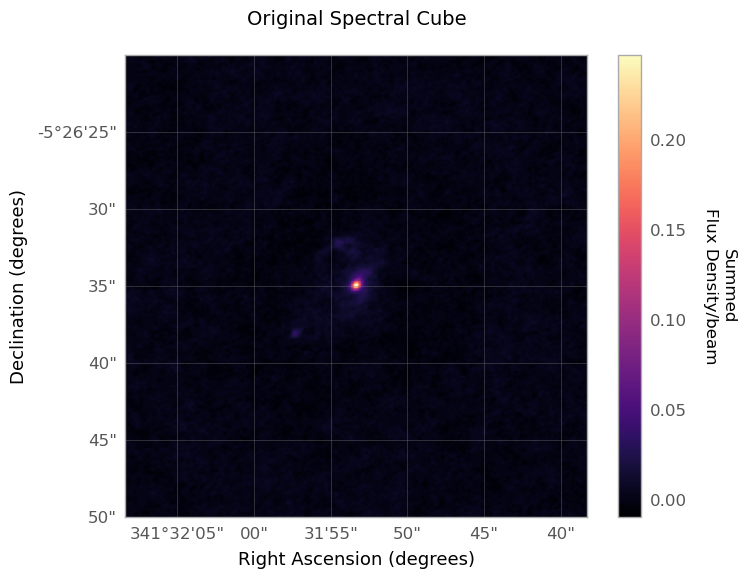

In [470]:
import numpy as np
import scarlet
import astropy.io.fits as fits
from spectral_cube import SpectralCube
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
import matplotlib
import matplotlib.pyplot as plt
from astropy.visualization import quantity_support, astropy_mpl_style
from astropy.modeling import models, fitting

# Enable the astropy plotting theme and quantity support
plt.style.use(astropy_mpl_style)
quantity_support()

# use a superior colormap and don't interpolate the pixels
matplotlib.rc('image', interpolation='none', origin="lower")
matplotlib.rc('grid', linestyle='-', linewidth=0.5, color='gray', alpha=0.5)

cube_type = 'C2_125'

fname = '/Users/arnablahiry/Desktop/Work/data/W2246/W2246_{}.fits'.format(cube_type)

hdul = fits.open(fname)
wcs = WCS(hdul[0].header)

fig = plt.figure()
fig.add_subplot(projection=wcs[0,0])
plt.title('Original Spectral Cube\n', fontsize = 14)
plt.imshow(np.sum(hdul[0].data[0], axis = 0), cmap = 'magma')
cbar = plt.colorbar()
cbar.set_label('Summed\nFlux Density/beam', rotation = 270, labelpad=35, fontsize = 12)
plt.xlabel('Right Ascension (degrees)', fontsize = 13)
plt.ylabel('Declination (degrees)', fontsize = 13)
ax = fig.gca()
ra = ax.coords[0]
dec = ax.coords[1]
ra.set_format_unit('degree')
dec.set_format_unit('degree')
plt.show()

In [22]:
'''np.save('/Users/arnablahiry/Desktop/cube_data.npy', hdul[0].data[0])'''

"np.save('/Users/arnablahiry/Desktop/cube_data.npy', hdul[0].data[0])"

In [501]:
#cube = SpectralCube.read('/Users/arnablahiry/Desktop/Work/data/W2246/W2246_C2_contsub_125.fits')
def crop_spectral_cube(cube, zlims, ylims, xlims, box, save = False, verbose = False):

    if verbose:
        print('\n\nOriginal Cube details:\n\n', cube)

    if zlims is not None:
        z_min, z_max =  zlims[0], zlims[1]
    else:
        z_min, z_max =  0, cube.shape[0] # Pixel range in the spectral dimension
    x_min, x_max =  xlims[0], xlims[1] # Pixel range in the first spatial dimension
    y_min, y_max =  ylims[0], ylims[1] # Pixel range in the second spatial dimension
    
    # Crop the spectral cube
    cropped_cube = cube[z_min:z_max, y_min:y_max, x_min:x_max]

    if verbose:
        # Print basic information about the cropped cube
        print('\n\nCropped Cube details:\n\n', cropped_cube)

    # Optionally, save the cropped cube to a new FITS file

    if box == None:
        if zlims is not None:
            fname_cropped = '/Users/arnablahiry/Desktop/Work/data/W2246/CROPPED_SPATIAL_AND_SPECTRAL_W2246_{}.fits'.format(cube_type)
        else:
            fname_cropped = '/Users/arnablahiry/Desktop/Work/data/W2246/CROPPED_ONLY_SPATIAL_W2246_{}.fits'.format(cube_type)

    else:
        if zlims is not None:
            fname_cropped = '/Users/arnablahiry/Desktop/Work/data/W2246/boxes/CROPPED_SPATIAL_AND_SPECTRAL_W2246_{}_box_{}.fits'.format(cube_type, box)
        else:
            fname_cropped = '/Users/arnablahiry/Desktop/Work/data/W2246/boxes/CROPPED_ONLY_SPATIAL_W2246_{}_box_{}.fits'.format(cube_type, box)

    if save:
        cropped_cube.write(fname_cropped, overwrite=True)

    cropped_wcs = cropped_cube.wcs

    if zlims is not None:
        print('Cube cropped BOTH spatially and spectrally')
    else:
        print('Cube cropped ONLY SPATIALLY, keeping all spectral slices\n')
    return cropped_cube, cropped_wcs

# Obtaining the associated frequency (GHz) for each spectral slice


xlims = (175, 375)
ylims = (200, 400)
zlims = (71, 99)

cube = SpectralCube.read(fname)

cropped_cube, cropped_wcs = crop_spectral_cube(cube, zlims=None, ylims=ylims, xlims=xlims, box = None, save=True, verbose=True)



Original Cube details:

 VaryingResolutionSpectralCube with shape=(125, 600, 600) and unit=Jy / beam:
 n_x:    600  type_x: RA---SIN  unit_x: deg    range:   341.527299 deg:  341.535656 deg
 n_y:    600  type_y: DEC--SIN  unit_y: deg    range:    -5.447217 deg:   -5.438897 deg
 n_s:    125  type_s: FREQ      unit_s: Hz     range: 337553872041.441 Hz:341062666492.100 Hz


Cropped Cube details:

 VaryingResolutionSpectralCube with shape=(125, 200, 200) and unit=Jy / beam:
 n_x:    200  type_x: RA---SIN  unit_x: deg    range:   341.530438 deg:  341.533215 deg
 n_y:    200  type_y: DEC--SIN  unit_y: deg    range:    -5.444439 deg:   -5.441675 deg
 n_s:    125  type_s: FREQ      unit_s: Hz     range: 337553872041.441 Hz:341062666492.100 Hz
Cube cropped ONLY SPATIALLY, keeping all spectral slices



In [505]:
data = np.asarray(cropped_cube.unmasked_data[:].T)

np.save('/Users/arnablahiry/Desktop/cube_data.npy', data)

/opt/anaconda3/lib/python3.11/site-packages/radio_beam/multiple_beams.py:286: UserWarning: Do not use the average beam for convolution! Use the smallest common beam from `Beams.common_beam()`.
  warnings.warn("Do not use the average beam for convolution! Use the"


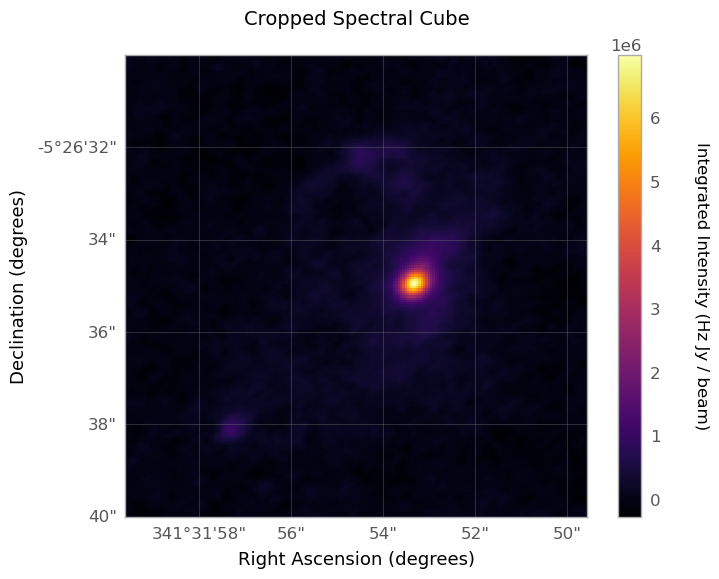

In [503]:

fig = plt.figure()
fig.add_subplot(projection=cropped_wcs[0])
plt.title('Cropped Spectral Cube\n', fontsize = 14)

moment0_map = cropped_cube.moment(order=0)
plt.imshow(moment0_map.value, cmap = 'inferno')
cbar = plt.colorbar()
cbar.set_label(f'Integrated Intensity ({moment0_map.unit})', rotation = 270, labelpad=35, fontsize = 12)
plt.xlabel('Right Ascension (degrees)', fontsize = 13)
plt.ylabel('Declination (degrees)', fontsize = 13)
ax = fig.gca()
ra = ax.coords[0]
dec = ax.coords[1]
ra.set_format_unit('degree')
dec.set_format_unit('degree')
plt.show()


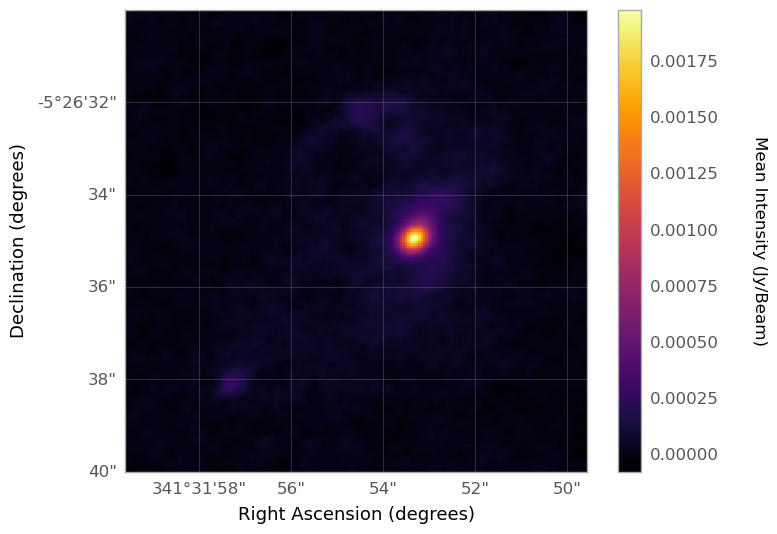

In [26]:
mean_map = cropped_cube.unmasked_data[:].mean(axis=0)

fig = plt.figure()
fig.add_subplot(projection=cropped_wcs[0])
plt.imshow(mean_map.value, cmap = 'inferno')
cbar = plt.colorbar()
cbar.set_label(f'Mean Intensity (Jy/Beam)', rotation = 270, labelpad=35, fontsize = 12)
plt.xlabel('Right Ascension (degrees)', fontsize = 13)
plt.ylabel('Declination (degrees)', fontsize = 13)
ax = fig.gca()
ra = ax.coords[0]
dec = ax.coords[1]
ra.set_format_unit('degree')
dec.set_format_unit('degree')
plt.show()


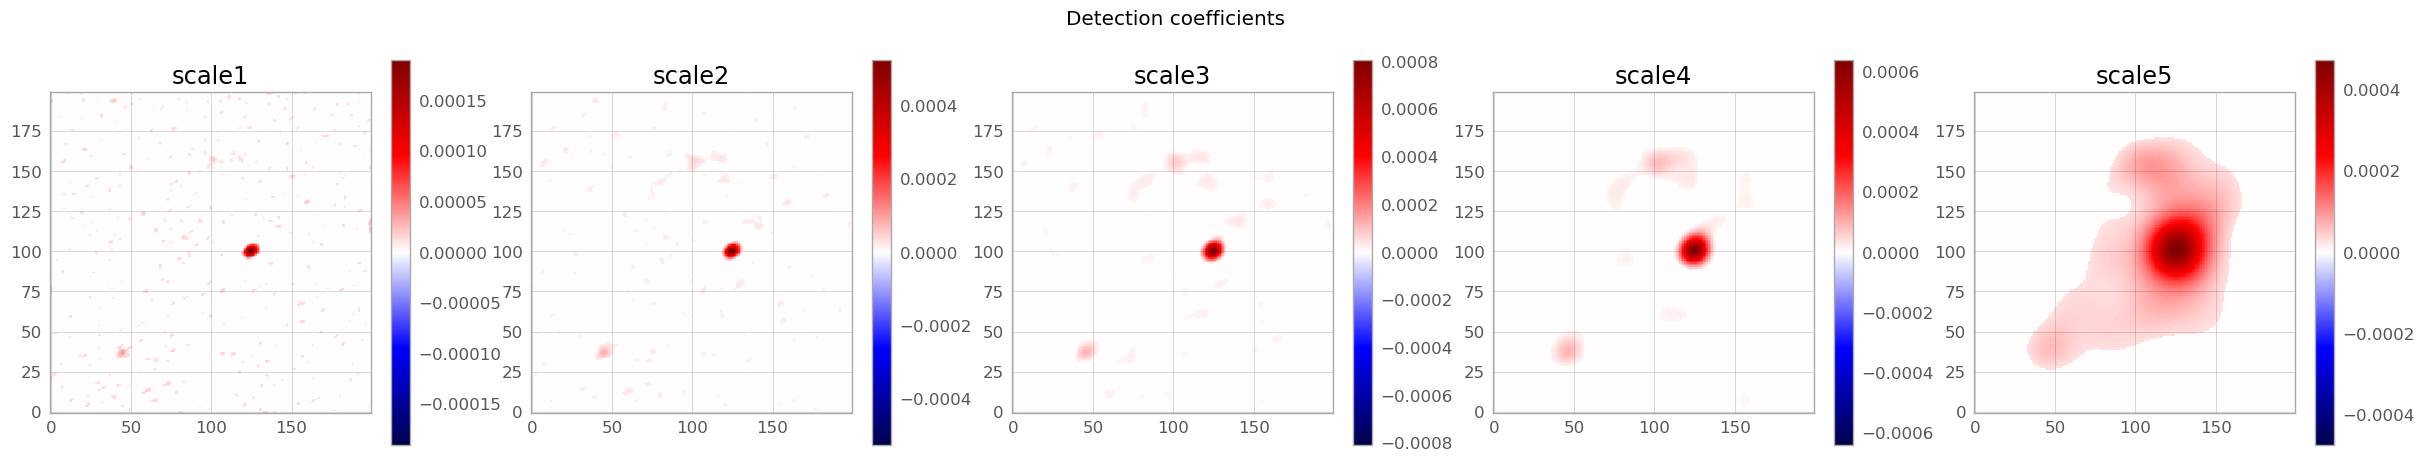

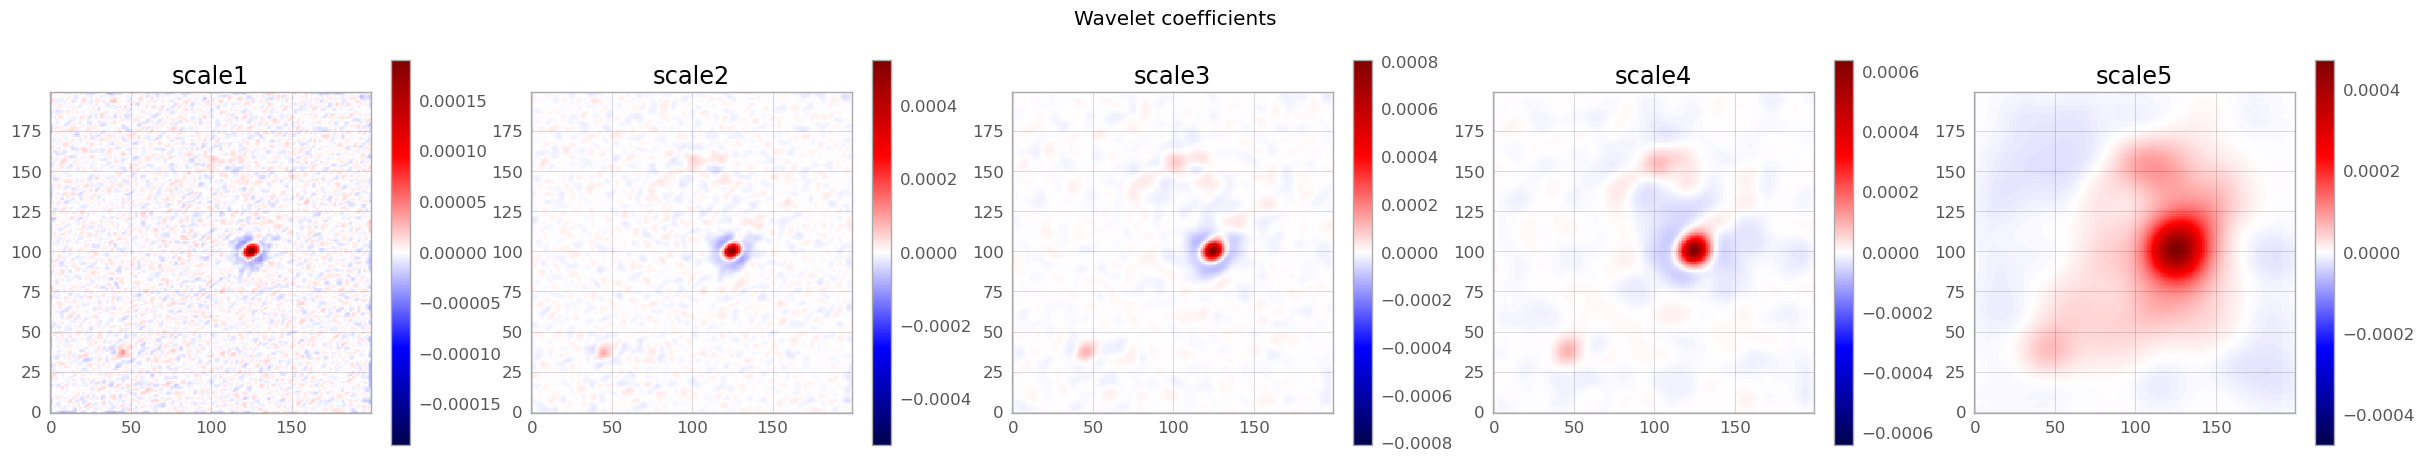

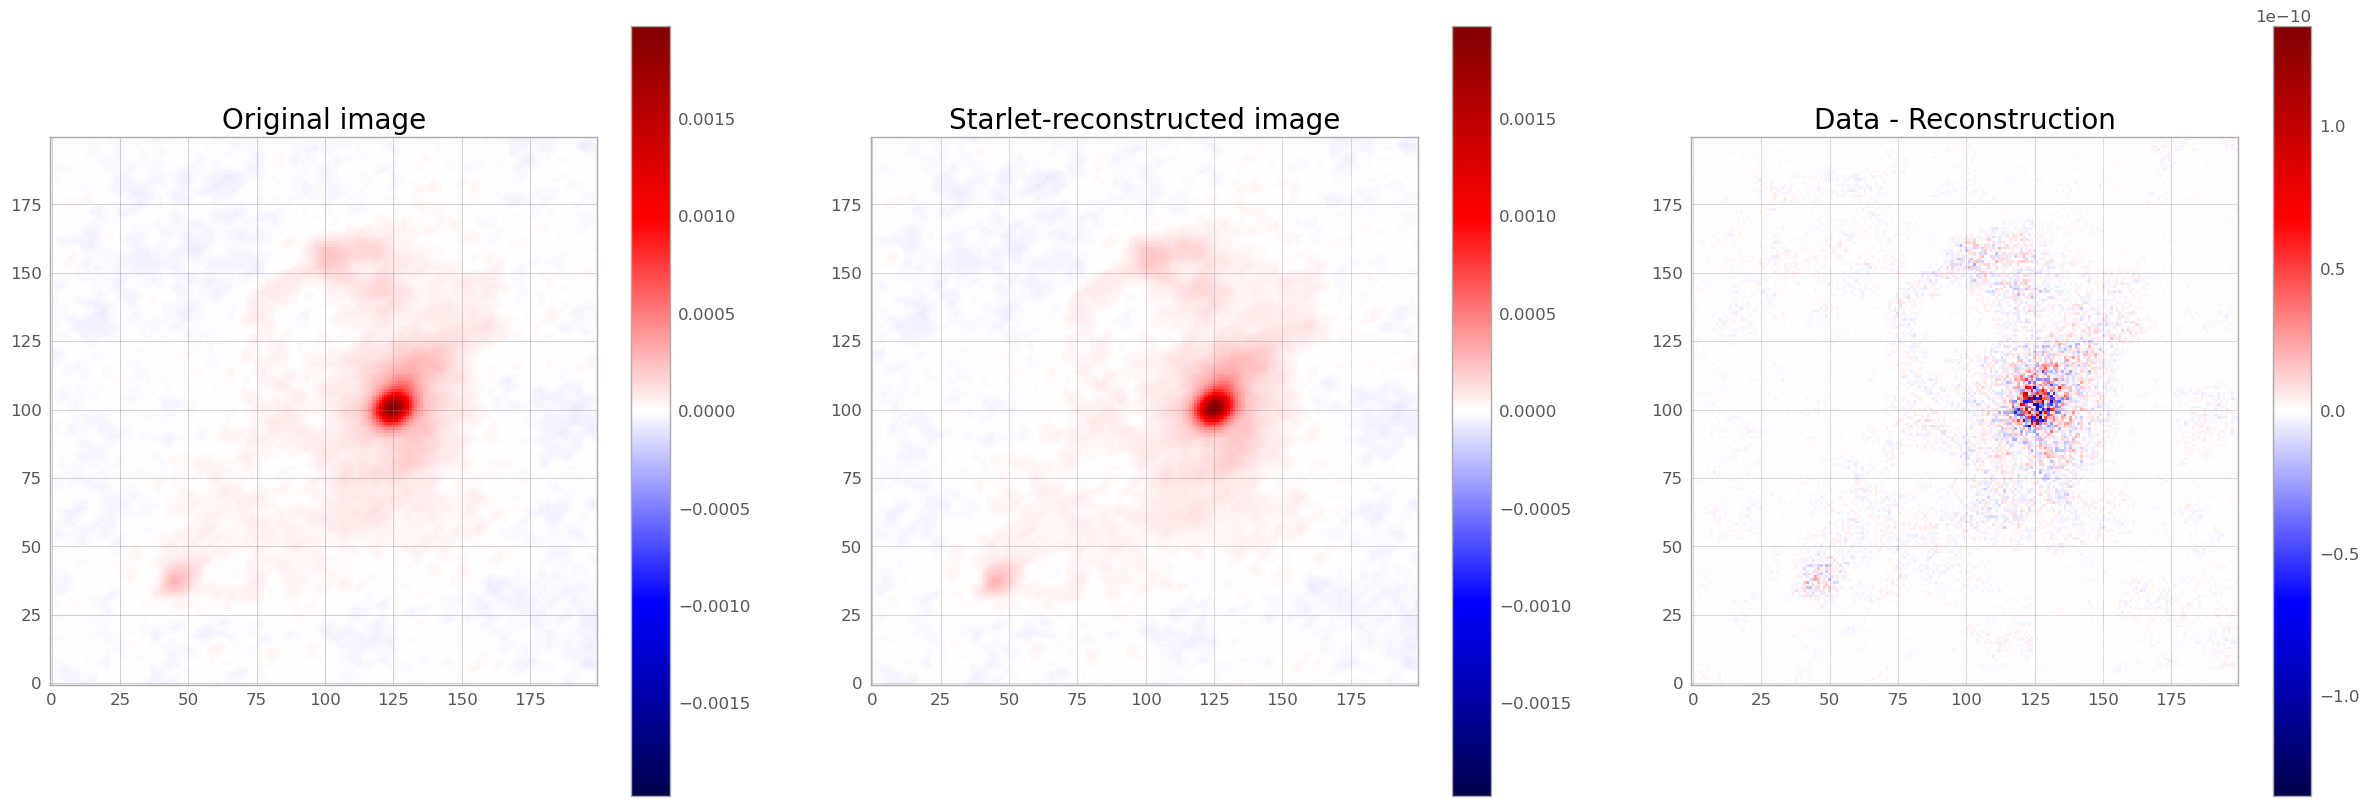

(200, 200)


/opt/anaconda3/lib/python3.11/site-packages/radio_beam/multiple_beams.py:286: UserWarning: Do not use the average beam for convolution! Use the smallest common beam from `Beams.common_beam()`.
  warnings.warn("Do not use the average beam for convolution! Use the"
/opt/anaconda3/lib/python3.11/site-packages/radio_beam/multiple_beams.py:286: UserWarning: Do not use the average beam for convolution! Use the smallest common beam from `Beams.common_beam()`.
  warnings.warn("Do not use the average beam for convolution! Use the"


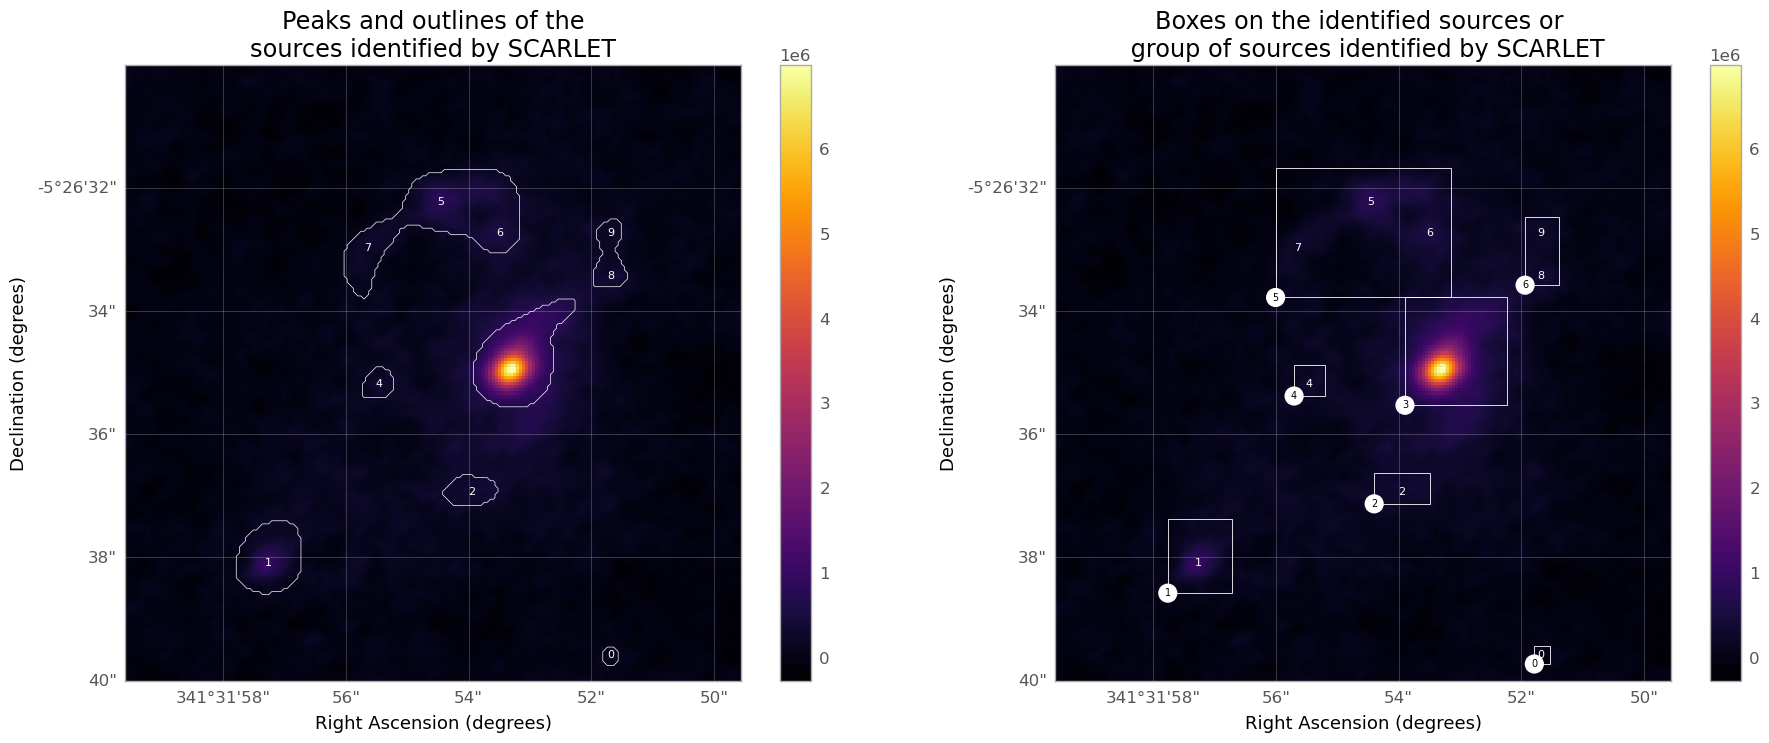

In [27]:


# §§ ------------------------------------------------ Creating a Starlet scales-based detections of broad spatial positions of interest ----------------------------------------------------§§

   
# Create a detection image by summing the images in all bands
# (a more rigorous approach would be to create a chi^2 coadd).

detect_image = mean_map.value

# Define a rough standard deviation for the image.
# This does not have to be exact, as it is fit by the
# get_multiresolution_support algorithm below.
sigma = 0.3
# Find the wavelet coefficients
coeffs = scarlet.wavelet.starlet_transform(detect_image, scales=4)
# Determine the significant coefficients
# (as defined in Starck et. al 2011)
M = scarlet.wavelet.get_multiresolution_support(detect_image, coeffs, sigma, K=2.3, epsilon=1e-1, max_iter=20)
# Use the multi-resolution support to select only
# the relevant pixels for detection
detect = M * coeffs
# We are only detecting positive peaks, so there
# is no need to include the negative coefficients
detect[detect<0] = 0

# Display the detection coefficients
lvl = detect.shape[0]
plt.figure(figsize = (lvl*5+5,5))
plt.suptitle('Detection coefficients')
for i in range(lvl):
    plt.subplot(1,lvl,i+1)
    plt.title('scale'+str(i+1))
    img = detect[i]
    img = np.arcsinh(10*img)/10
    vmax = np.max(np.abs(img))
    plt.imshow(img, cmap="seismic", vmin=-vmax, vmax=vmax)
    plt.colorbar()
    plt.grid(color='black', linewidth=0.5, alpha=0.2)
plt.show()

# Display the detection coefficients
lvl = detect.shape[0]
plt.figure(figsize = (lvl*5+5,5))
plt.suptitle('Wavelet coefficients')
for i in range(lvl):
    plt.subplot(1,lvl,i+1)
    plt.title('scale'+str(i+1))
    img = coeffs[i]
    img = np.arcsinh(10*img)/10
    vmax = np.max(np.abs(img))
    plt.imshow(img, cmap="seismic", vmin=-vmax, vmax=vmax)
    plt.colorbar()
    plt.grid(color='black', linewidth=0.5, alpha=0.2)
plt.show()

reconstruction = scarlet.wavelet.starlet_reconstruction(coeffs)
residual = detect_image - reconstruction

#Making sure we recover the original image:
plt.figure(figsize = (30,10))
plt.subplot(131)
plt.title('Original image', fontsize = 20)
vmax = np.max(np.abs(detect_image))
plt.imshow(detect_image, cmap="seismic", vmin=-vmax, vmax=vmax)
plt.colorbar()
plt.subplot(132)
plt.title('Starlet-reconstructed image', fontsize = 20)
vmax = np.max(np.abs(reconstruction))
plt.imshow(reconstruction, cmap="seismic", vmin=-vmax, vmax=vmax)
plt.colorbar()
plt.grid(color='black', linewidth=0.5, alpha=0.2)

plt.subplot(133)
plt.title('Data - Reconstruction', fontsize = 20)
vmax = np.max(np.abs(residual))
plt.imshow(residual, cmap="seismic", vmin=-vmax, vmax=vmax)
plt.colorbar()
plt.grid(color='black', linewidth=0.5, alpha=0.2)


plt.show()

from scarlet.detect_pybind11 import get_footprints

# Calculate isolated footprints and their maxima
# in the 2nd wavelet scale.
footprints = get_footprints(detect[3], min_separation=0, min_area=10, thresh=0)

# Display all of the footprints
footprint_img = np.zeros(detect.shape[1:])
peaks = []
boxes = []

for fp in footprints:
    bbox = scarlet.detect.bounds_to_bbox(fp.bounds)
    boxes.append(bbox)
    footprint_img[bbox.slices] = fp.footprint
    peaks += list(fp.peaks)


print(footprint_img.shape)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize = (22,8), subplot_kw={'projection': cropped_wcs[0]})

# Peaks and Footprints on the original image

im0 = ax[0].imshow(cropped_cube.moment(order=0).value, cmap = 'inferno')
cbar0 = fig.colorbar(im0, ax = ax[0])
ax[0].contour(footprint_img, [0.5,], colors='w', linewidths=0.5)
for k, peak in enumerate(peaks):
    ax[0].text(peak.x, peak.y, str(k), color="w", ha='center', va='center', size=8)
ax[0].set_title('Peaks and outlines of the\nsources identified by SCARLET')
ax[0].grid(True, color='white', linewidth=0.5, alpha=0.3)
ax[0].set_xlabel('Right Ascension (degrees)', fontsize = 13)
ax[0].set_ylabel('Declination (degrees)', fontsize = 13)
ra = ax[0].coords[0]
dec = ax[0].coords[1]
ra.set_format_unit('degree')
dec.set_format_unit('degree')

# Boxes on the original image

box_sizes = []
origins = []

bbox_props = dict(boxstyle="circle,pad=0.4", fc="white", ec="white", lw=1)

for i in range(len(boxes)):
    box_sizes.append(boxes[i].shape)
    origins.append(boxes[i].origin)

im1 = ax[1].imshow(cropped_cube.moment(order=0).value, cmap = 'inferno')
cbar1 = fig.colorbar(im1, ax = ax[1])
for k in range(len(origins)):
    rect = rect = matplotlib.patches.Rectangle((origins[k][1], origins[k][0]), box_sizes[k][1], box_sizes[k][0], linewidth=0.6, edgecolor='white', facecolor='none')
    # Add the box to the plot
    ax[1].add_patch(rect)
    ax[1].text(origins[k][1], origins[k][0], k, ha="center", va="center", size=7, bbox=bbox_props)

for k, peak in enumerate(peaks):
    ax[1].text(peak.x, peak.y, str(k), color="w", ha='center', va='center', size=8)
ax[1].set_title('Boxes on the identified sources or \n group of sources identified by SCARLET')
ax[1].grid(True, color='white', linewidth=0.5, alpha=0.3)
ax[1].set_xlabel('Right Ascension (degrees)', fontsize = 13)
ax[1].set_ylabel('Declination (degrees)', fontsize = 13)
ra = ax[1].coords[0]
dec = ax[1].coords[1]
ra.set_format_unit('degree')
dec.set_format_unit('degree')

plt.show()

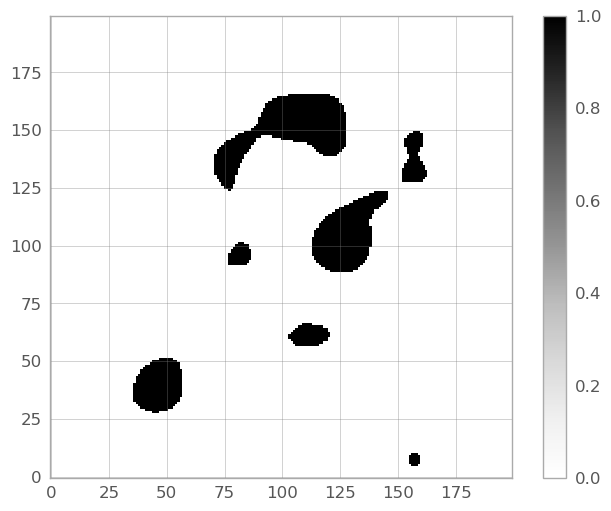

In [28]:
plt.imshow(footprint_img, cmap = 'Greys')
plt.colorbar()



Original Cube details:

 VaryingResolutionSpectralCube with shape=(125, 200, 200) and unit=Jy / beam:
 n_x:    200  type_x: RA---SIN  unit_x: deg    range:   341.530438 deg:  341.533215 deg
 n_y:    200  type_y: DEC--SIN  unit_y: deg    range:    -5.444439 deg:   -5.441675 deg
 n_s:    125  type_s: FREQ      unit_s: Hz     range: 337553872041.441 Hz:341062666492.100 Hz


Cropped Cube details:

 VaryingResolutionSpectralCube with shape=(28, 42, 57) and unit=Jy / beam:
 n_x:     57  type_x: RA---SIN  unit_x: deg    range:   341.531443 deg:  341.532224 deg
 n_y:     42  type_y: DEC--SIN  unit_y: deg    range:    -5.442717 deg:   -5.442147 deg
 n_s:     28  type_s: FREQ      unit_s: Hz     range: 338289587006.902 Hz:339053598701.803 Hz
Cube cropped BOTH spatially and spectrally
(28, 42, 57)


/opt/anaconda3/lib/python3.11/site-packages/radio_beam/multiple_beams.py:286: UserWarning: Do not use the average beam for convolution! Use the smallest common beam from `Beams.common_beam()`.
  warnings.warn("Do not use the average beam for convolution! Use the"


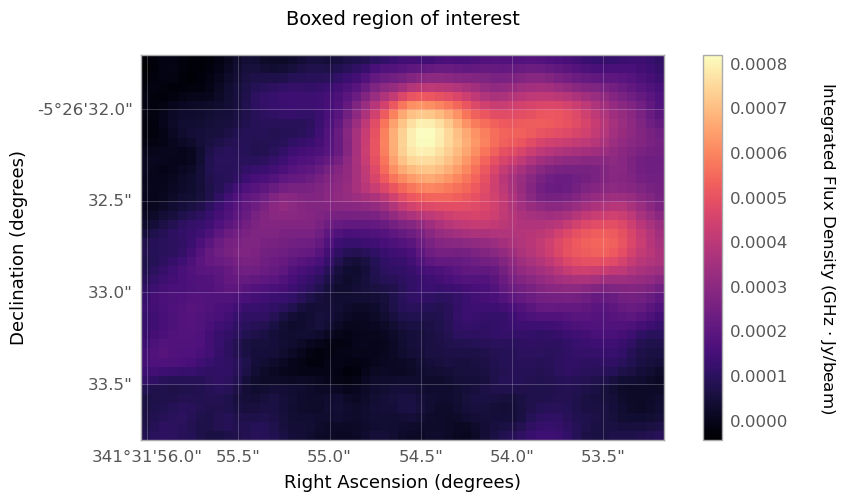

In [357]:
import numpy as np
from astropy.visualization import astropy_mpl_style
from astropy.visualization.wcsaxes import WCSAxes
import imageio


plt.style.use(astropy_mpl_style)  # Set the Astropy style for plotting


box = 5
y0, x0 = origins[box]
box_height, box_width = box_sizes[box][0], box_sizes[box][1]


xlims = (x0, x0+box_width)
ylims = (y0, y0+box_height)
#zlims = (71,99)

boxed_cube, boxed_wcs = crop_spectral_cube(cropped_cube, zlims, ylims, xlims, box=box, save=True, verbose=True)

print(boxed_cube.shape)

'''spectral_cube, wcs_boxed = crop_box(x0, y0, box_height, box_width)


print(spectral_cube.shape)
'''

#plt.imshow(np.sum(spectral_cube, axis=0))

fig = plt.figure(figsize = (10,5))
fig.add_subplot(projection=boxed_wcs[0])
plt.title('Boxed region of interest\n', fontsize = 14)
plt.imshow(boxed_cube.moment(order=0).value/1e9, cmap = 'magma')
cbar = plt.colorbar()
cbar.set_label(r'Integrated Flux Density (GHz $\cdot$ Jy/beam)', rotation = 270, labelpad=35, fontsize = 12)
plt.xlabel('Right Ascension (degrees)', fontsize = 13)
plt.ylabel('Declination (degrees)', fontsize = 13)
ax = fig.gca()
ra = ax.coords[0]
dec = ax.coords[1]
ra.set_format_unit('degree')
dec.set_format_unit('degree')
plt.grid(color='white', linewidth=0.5, alpha=0.3)
plt.show()

make_gif = False

if make_gif==True:
    frequencies = boxed_cube.spectral_axis.to('GHz') #GHz
    image_files = []

    data_array = boxed_cube.unmasked_data[::].value

    for i in range(boxed_cube.shape[0]):
        fig = plt.figure(figsize=(boxed_cube[i].shape[1] + 20, boxed_cube[i].shape[0]))
        fig.add_subplot(projection = boxed_wcs[0])
        img = data_array[i,:,:]
        plt.imshow(img, cmap = 'inferno')
        plt.xlabel('Right Ascension (degrees)', fontsize = 65, labelpad=2)
        plt.ylabel('Declination (degrees)', fontsize = 65)
        ax = fig.gca()
        ra = ax.coords[0]
        dec = ax.coords[1]
        ra.set_format_unit('degree')
        dec.set_format_unit('degree')
        ra.set_ticklabel(size=50)
        dec.set_ticklabel(size=50)
        ra.tick_params(pad=50)
        dec.tick_params(pad=50)
        cbar = plt.colorbar()
        cbar.set_label(r'Flux Density (Jy/beam)', rotation = 270, labelpad=105, fontsize = 65)
        cbar.ax.tick_params(labelsize=50)  # Set the font size of the colorbar ticks
        plt.title('\nSlice #{} : Frequency = {:.2f}\n'.format(i+1, frequencies[i]), fontsize = 80)
        image_file = '/Users/arnablahiry/Desktop/Work/scarlet/gifs/plots_boxed_cube_1/detection_{}.png'.format(i)
        plt.savefig(image_file)
        plt.close(fig)
        image_files.append(image_file)

    # Create the GIF
    with imageio.get_writer('/Users/arnablahiry/Desktop/Work/scarlet/gifs/boxed_cube.gif'.format(i+2), mode='I', duration=4) as writer:
        for image_file in image_files:
            image = imageio.imread(image_file)
            writer.append_data(image)

In [358]:
from scarlet.detect_pybind11 import get_footprints

slice_detections_scale2 = []
slice_detections_scale3 = []

mask = []
masked_boxed_array = []
all_peaks = []

use_scale = 2

for i in range(boxed_cube.shape[0]):
    
    # Create a detection image by summing the images in all bands
    # (a more rigorous approach would be to create a chi^2 coadd).
    detect_image = boxed_cube[i]
    # Define a rough standard deviation for the image.
    # This does not have to be exact, as it is fit by the
    # get_multiresolution_support algorithm below.
    sigma = 0.3
    # Find the wavelet coefficients
    coeffs = scarlet.wavelet.starlet_transform(detect_image, scales=4)
    # Determine the significant coefficients
    # (as defined in Starck et. al 2011)
    M = scarlet.wavelet.get_multiresolution_support(detect_image, coeffs, sigma, K=3, epsilon=1e-1, max_iter=20)
    # Use the multi-resolution support to select only
    # the relevant pixels for detection
    detect = M * coeffs
    # We are only detecting positive peaks, so there
    # is no need to include the negative coefficients
    detect[detect<0] = 0

    slice_detections_scale2.append(detect[1])
    slice_detections_scale3.append(detect[2])
    


    # Calculate isolated footprints and their maxima
    # in the 2nd wavelet scale.
    footprints = get_footprints(detect[use_scale], min_separation=0, min_area=10, thresh=0)

    # Display all of the footprints
    footprint_img = np.zeros(detect.shape[1:])

    peaks = []
        
    for fp in footprints:
        bbox = scarlet.detect.bounds_to_bbox(fp.bounds)
        boxes.append(bbox)
        footprint_img[bbox.slices] = fp.footprint
        peaks += list(fp.peaks)
    mask.append(footprint_img)

    all_peaks.append(peaks)
    masked_boxed_array.append(footprint_img * boxed_cube[i])

    '''# Display the detection coefficients
    lvl = detect.shape[0]
    plt.figure(figsize = (lvl*5+5,5))
    plt.suptitle('Detection coefficients')
    for i in range(lvl):
        plt.subplot(1,lvl,i+1)
        plt.title('scale'+str(i+1))
        img = detect[i]
        img = np.arcsinh(10*img)/10
        vmax = np.max(np.abs(img))
        #vmax = 0.001
        plt.imshow(img, cmap="seismic", vmin=-vmax, vmax=vmax, origin = 'lower')
        plt.colorbar()
    plt.show()'''

    '''# Display the detection coefficients
    lvl = detect.shape[0]
    plt.figure(figsize = (lvl*5+5,5))
    plt.suptitle('Wavelet coefficients')
    for i in range(lvl):
        plt.subplot(1,lvl,i+1)
        plt.title('scale'+str(i+1))
        img = coeffs[i]
        img = np.arcsinh(10*img)/10
        vmax = np.max(np.abs(img))
        plt.imshow(img, cmap="seismic", vmin=-vmax, vmax=vmax)
        plt.colorbar()
    plt.show()'''

    '''reconstruction = scarlet.wavelet.starlet_reconstruction(coeffs)
    residual = detect_image - reconstruction'''

    '''#Making sure we recover the original image:
    plt.figure(figsize = (30,10))
    plt.subplot(131)
    plt.title('Original image', fontsize = 20)
    vmax = np.max(np.abs(detect_image))
    plt.imshow(detect_image, cmap="seismic", vmin=-vmax, vmax=vmax)
    plt.colorbar()
    plt.subplot(132)
    plt.title('Starlet-reconstructed image', fontsize = 20)
    vmax = np.max(np.abs(reconstruction))
    plt.imshow(reconstruction, cmap="seismic", vmin=-vmax, vmax=vmax)
    plt.colorbar()'''
    '''plt.subplot(133)
    plt.title('Data - Reconstruction', fontsize = 20)
    vmax = np.max(np.abs(residual))
    plt.imshow(residual, cmap="seismic", vmin=-vmax, vmax=vmax)
    plt.colorbar()
    plt.show()'''


mask = np.asarray(mask)
masked_boxed_array = np.asarray(masked_boxed_array)

In [359]:
masked_boxed_cube = SpectralCube(data=masked_boxed_array, wcs=boxed_cube.wcs, meta=boxed_cube.meta)

fname_masked = '/Users/arnablahiry/Desktop/Work/data/W2246/boxes/masked_W2246_{}_box_{}_scale_{}.fits'.format(cube_type, box, use_scale)
masked_boxed_cube.write(fname_masked, overwrite=True)

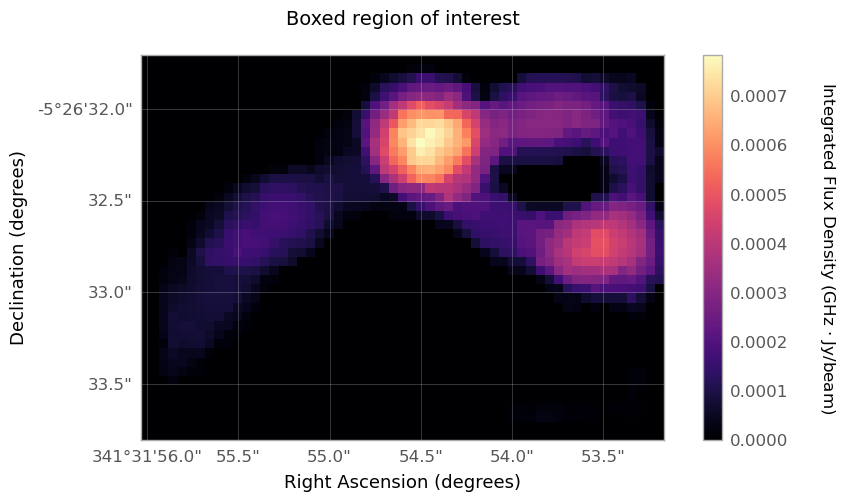

In [499]:
slice = 12

fig = plt.figure(figsize = (10,5))
fig.add_subplot(projection=boxed_wcs[0])
plt.title('Boxed region of interest\n', fontsize = 14)
plt.imshow(masked_boxed_cube.moment(order=0).value/1e9, cmap = 'magma')
cbar = plt.colorbar()
cbar.set_label(r'Integrated Flux Density (GHz $\cdot$ Jy/beam)', rotation = 270, labelpad=35, fontsize = 12)
plt.xlabel('Right Ascension (degrees)', fontsize = 13)
plt.ylabel('Declination (degrees)', fontsize = 13)
ax = fig.gca()
ra = ax.coords[0]
dec = ax.coords[1]
ra.set_format_unit('degree')
dec.set_format_unit('degree')
plt.grid(color='white', linewidth=0.5, alpha=0.3)
plt.show()

def make_gif(cube):
    frequencies = cube.spectral_axis.to('GHz') #GHz
    image_files = []

    data_array = boxed_cube.unmasked_data[::].value

    for i in range(boxed_cube.shape[0]):
        fig = plt.figure(figsize=(boxed_cube[i].shape[1] + 20, boxed_cube[i].shape[0]))
        fig.add_subplot(projection = boxed_wcs[0])
        img = data_array[i,:,:]
        plt.imshow(img, cmap = 'inferno')
        plt.xlabel('Right Ascension (degrees)', fontsize = 65, labelpad=2)
        plt.ylabel('Declination (degrees)', fontsize = 65)
        ax = fig.gca()
        ra = ax.coords[0]
        dec = ax.coords[1]
        ra.set_format_unit('degree')
        dec.set_format_unit('degree')
        ra.set_ticklabel(size=50)
        dec.set_ticklabel(size=50)
        ra.tick_params(pad=50)
        dec.tick_params(pad=50)
        cbar = plt.colorbar()
        cbar.set_label(r'Flux Density (Jy/beam)', rotation = 270, labelpad=105, fontsize = 65)
        cbar.ax.tick_params(labelsize=50)  # Set the font size of the colorbar ticks
        plt.title('\nSlice #{} : Frequency = {:.2f}\n'.format(i+1, frequencies[i]), fontsize = 80)
        image_file = '/Users/arnablahiry/Desktop/Work/scarlet/gifs/plots_boxed_cube_1/detection_{}.png'.format(i)
        plt.savefig(image_file)
        plt.close(fig)
        image_files.append(image_file)

    # Create the GIF
    with imageio.get_writer('/Users/arnablahiry/Desktop/Work/scarlet/gifs/boxed_cube.gif'.format(i+2), mode='I', duration=4) as writer:
        for image_file in image_files:
            image = imageio.imread(image_file)
            writer.append_data(image)



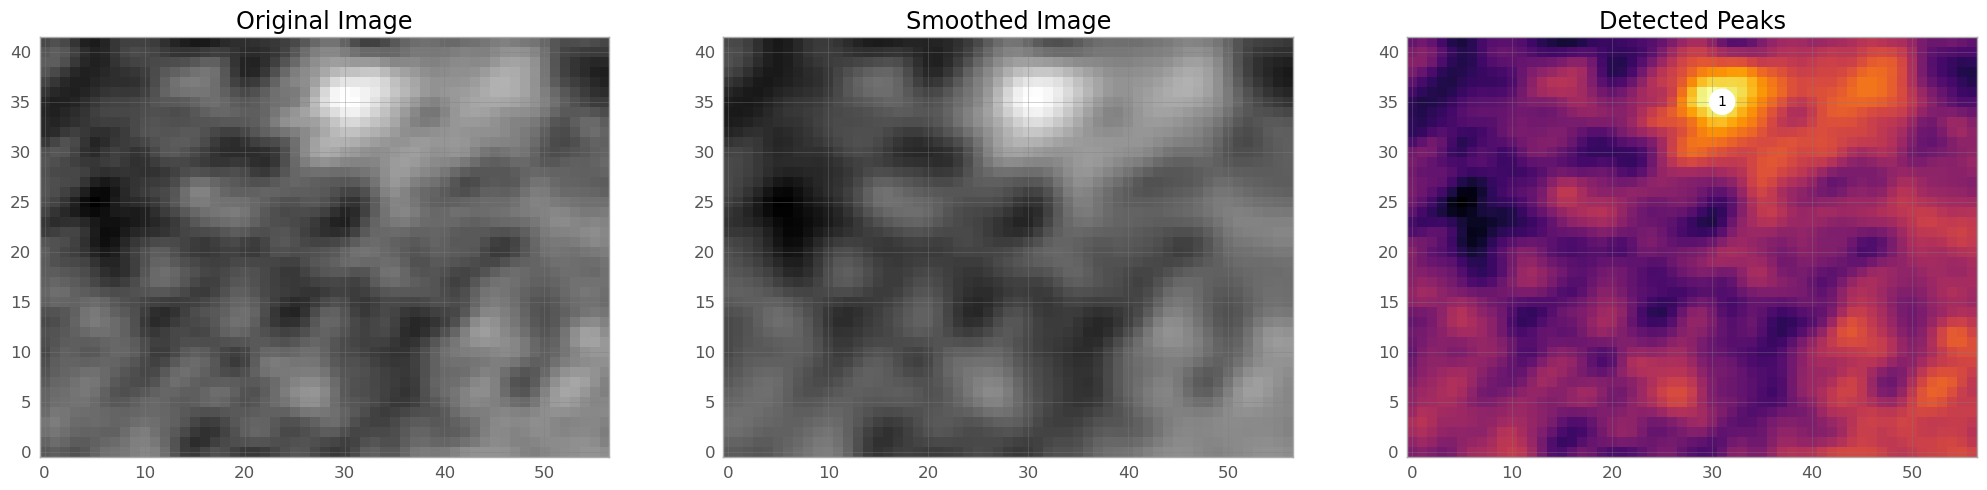

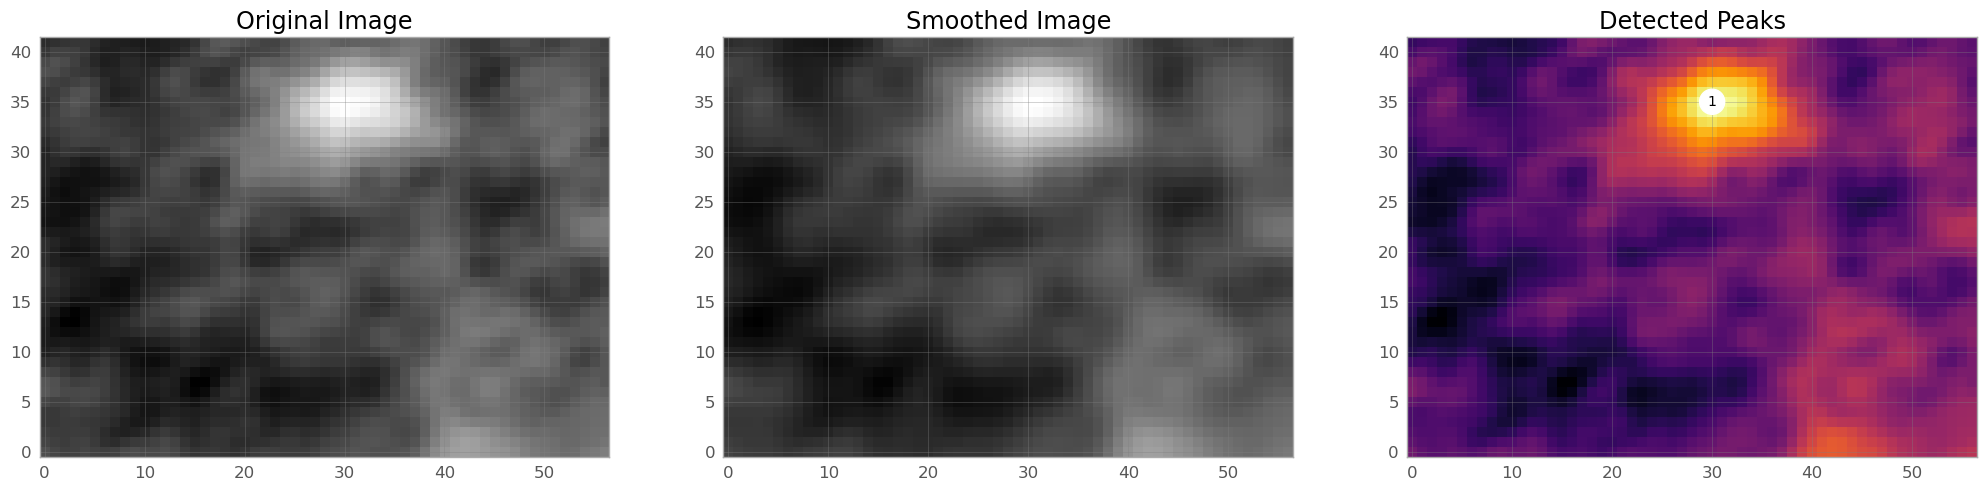

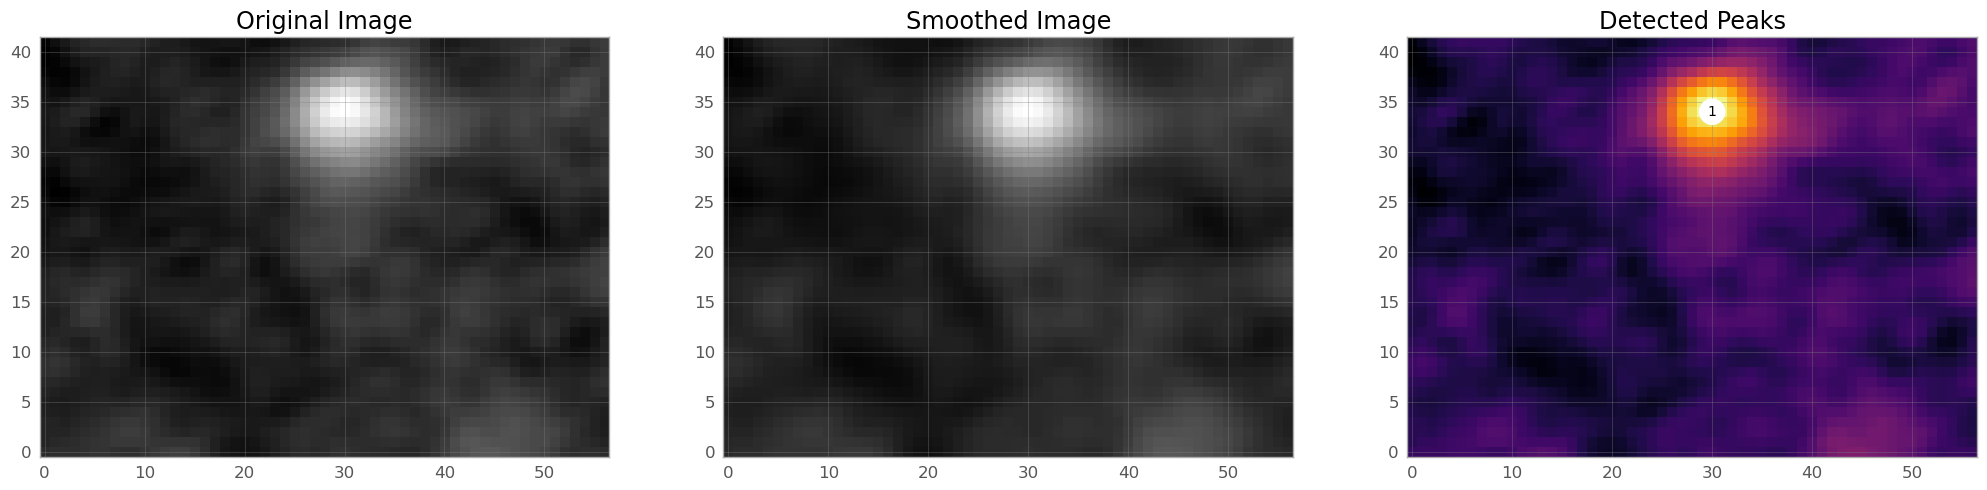

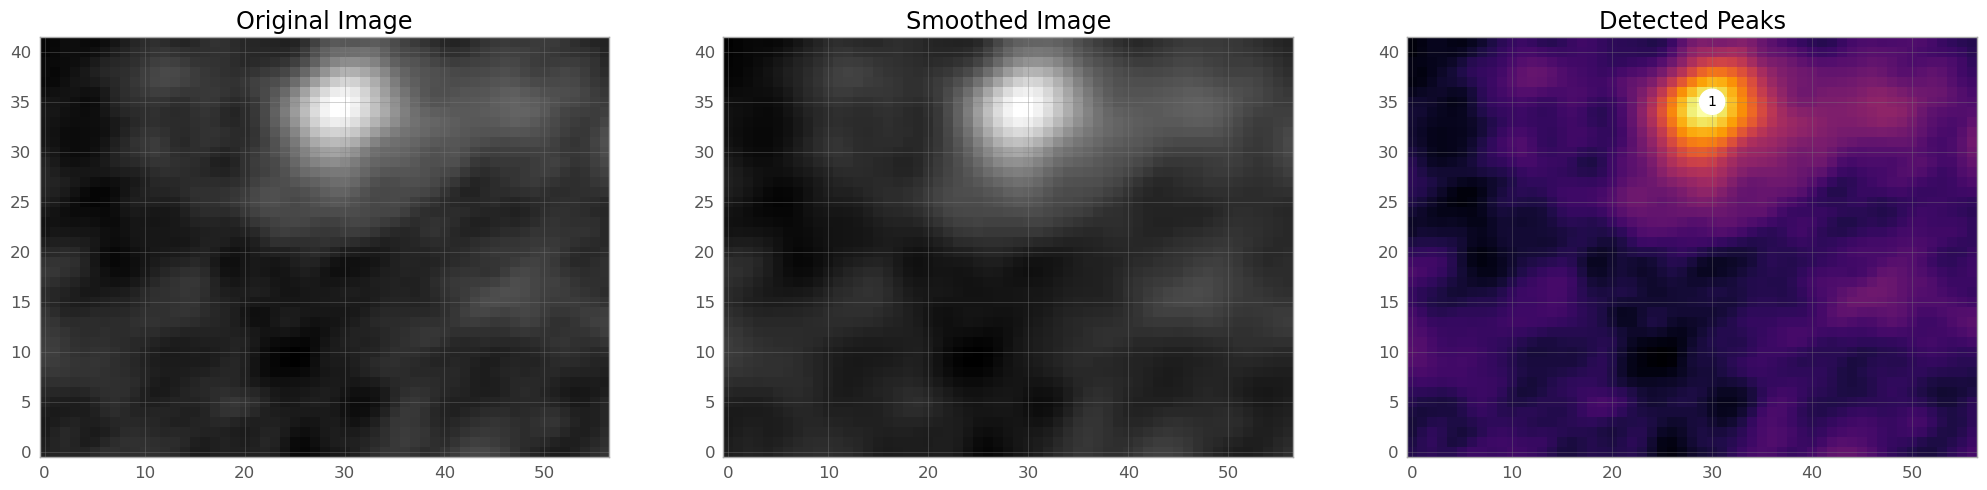

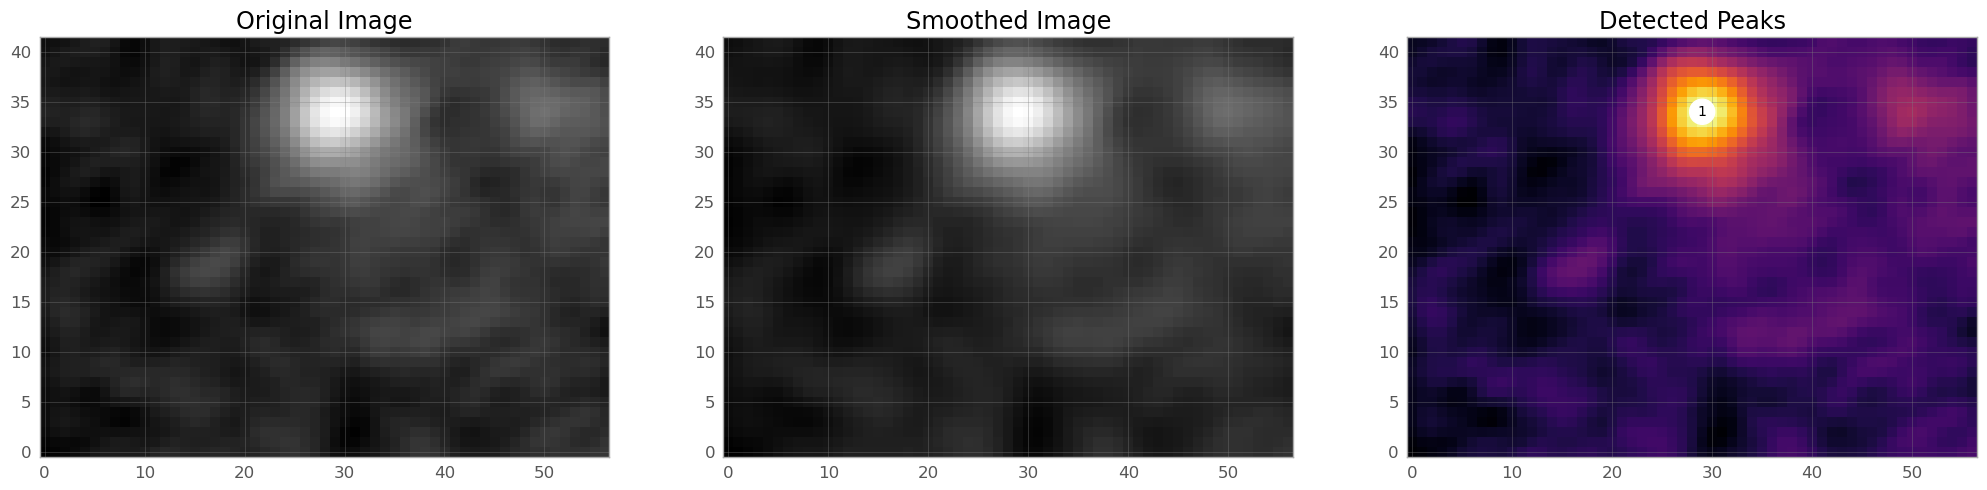

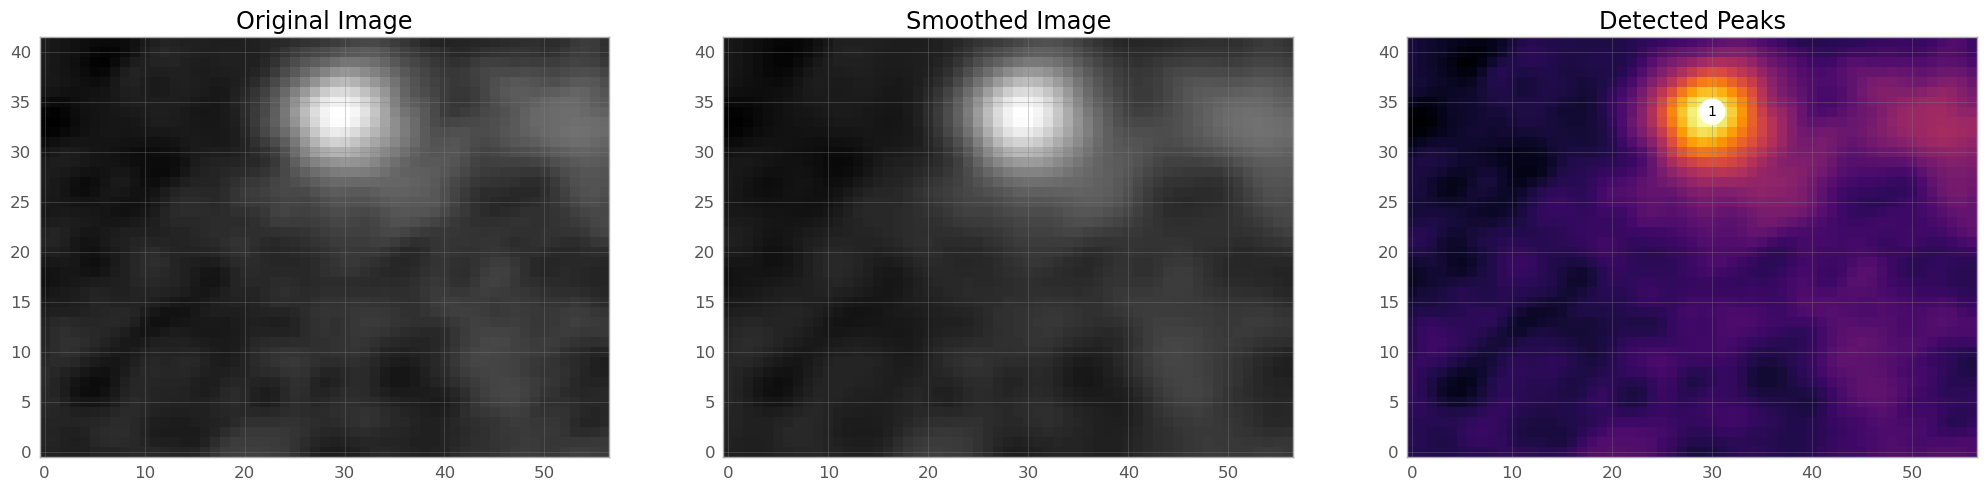

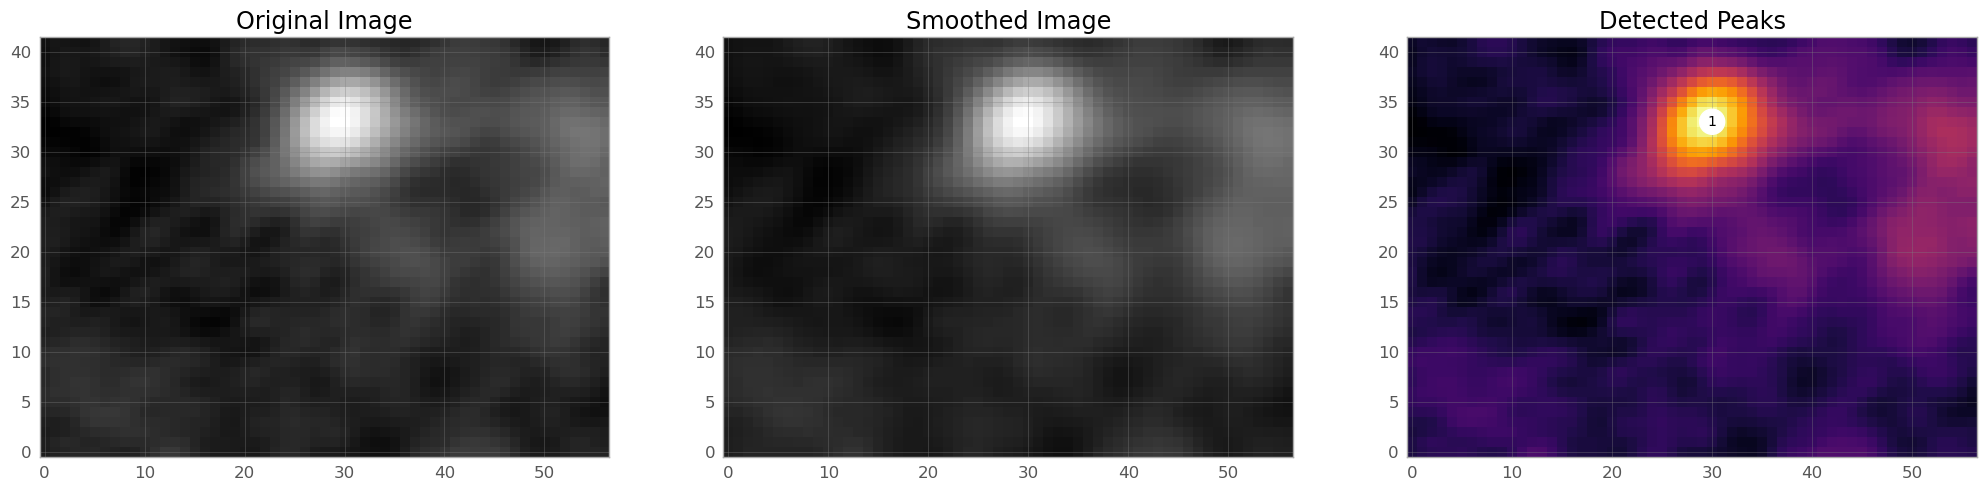

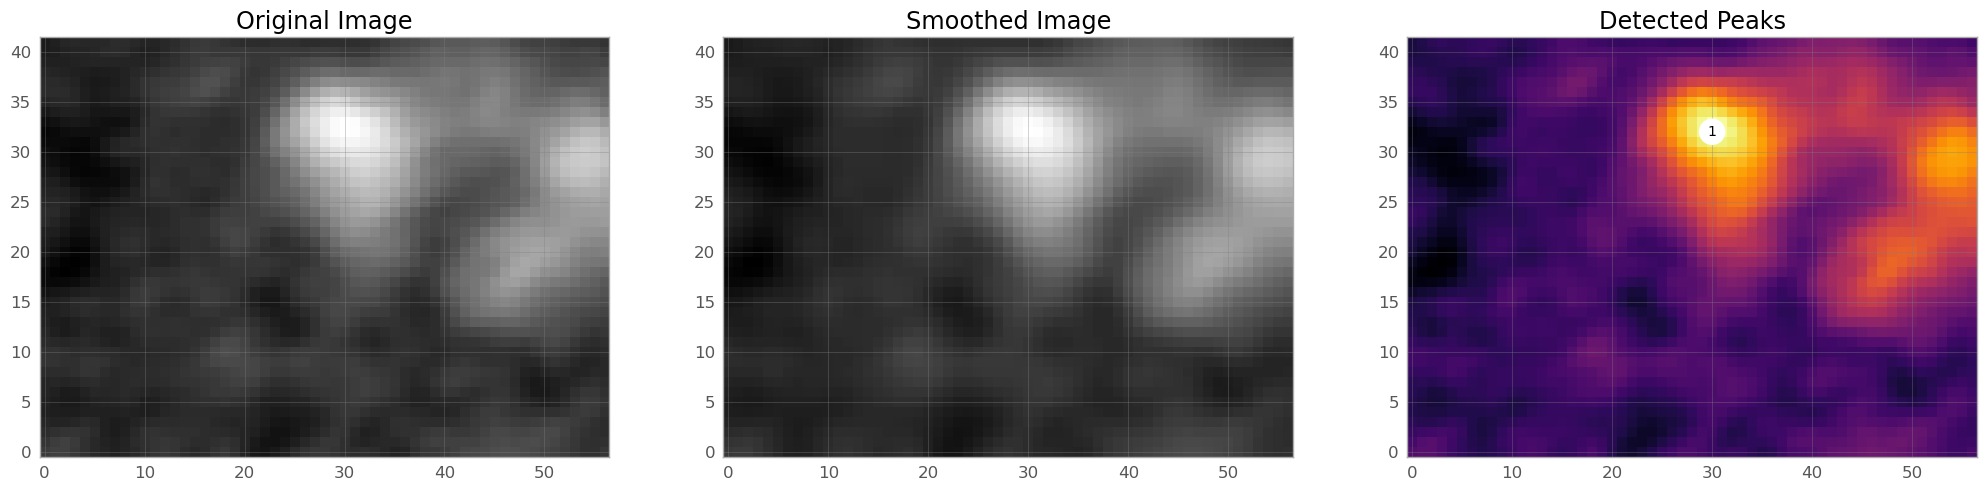

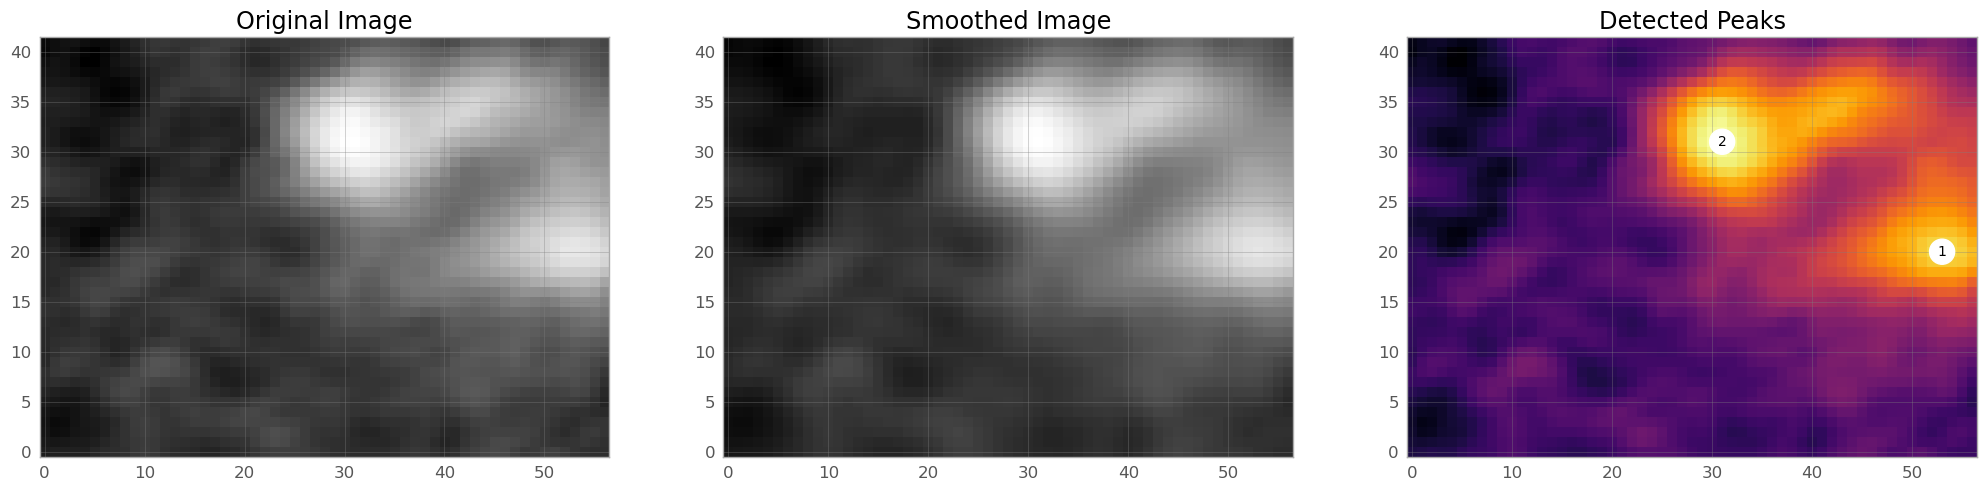

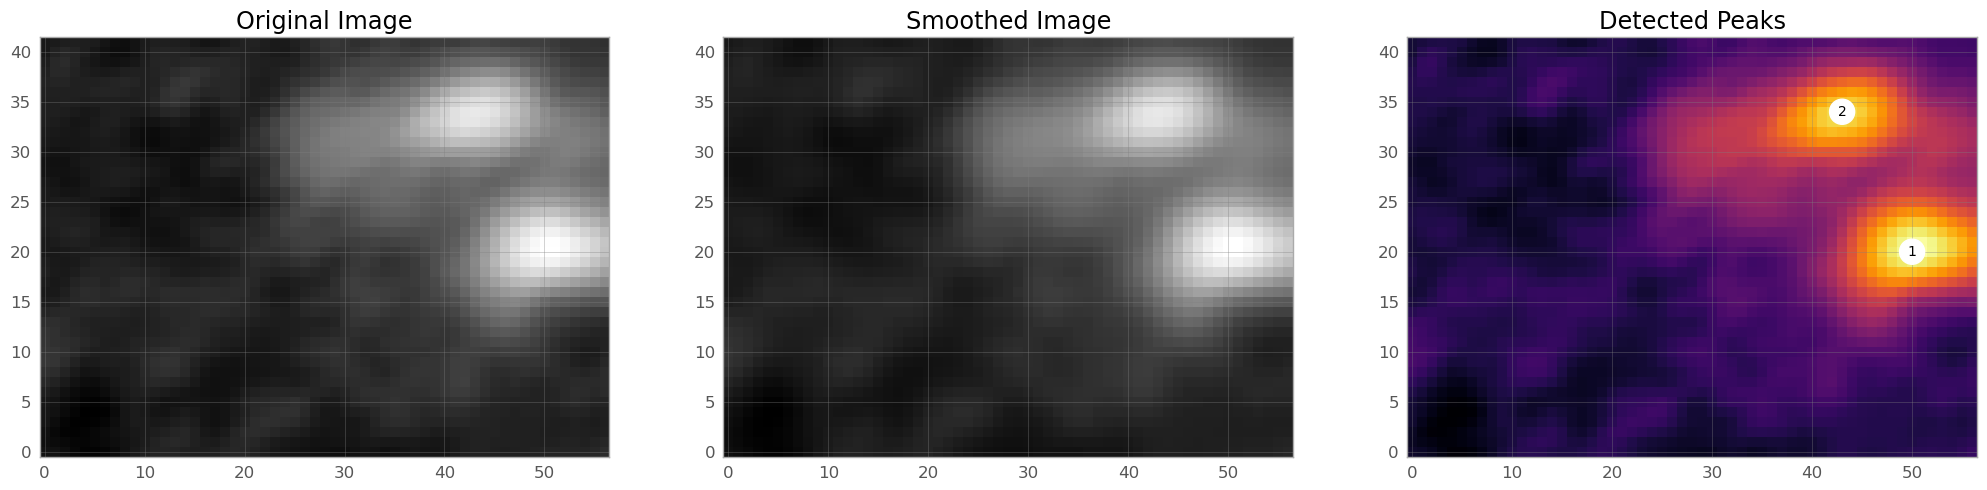

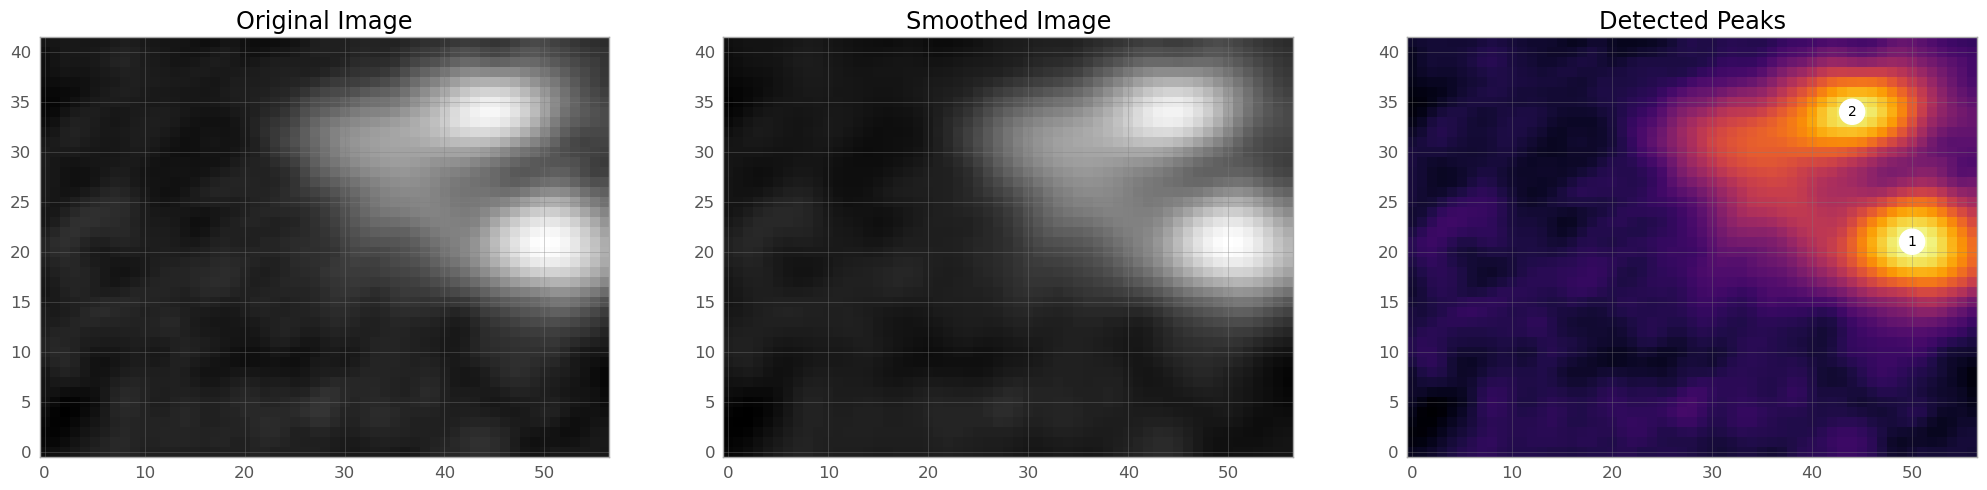

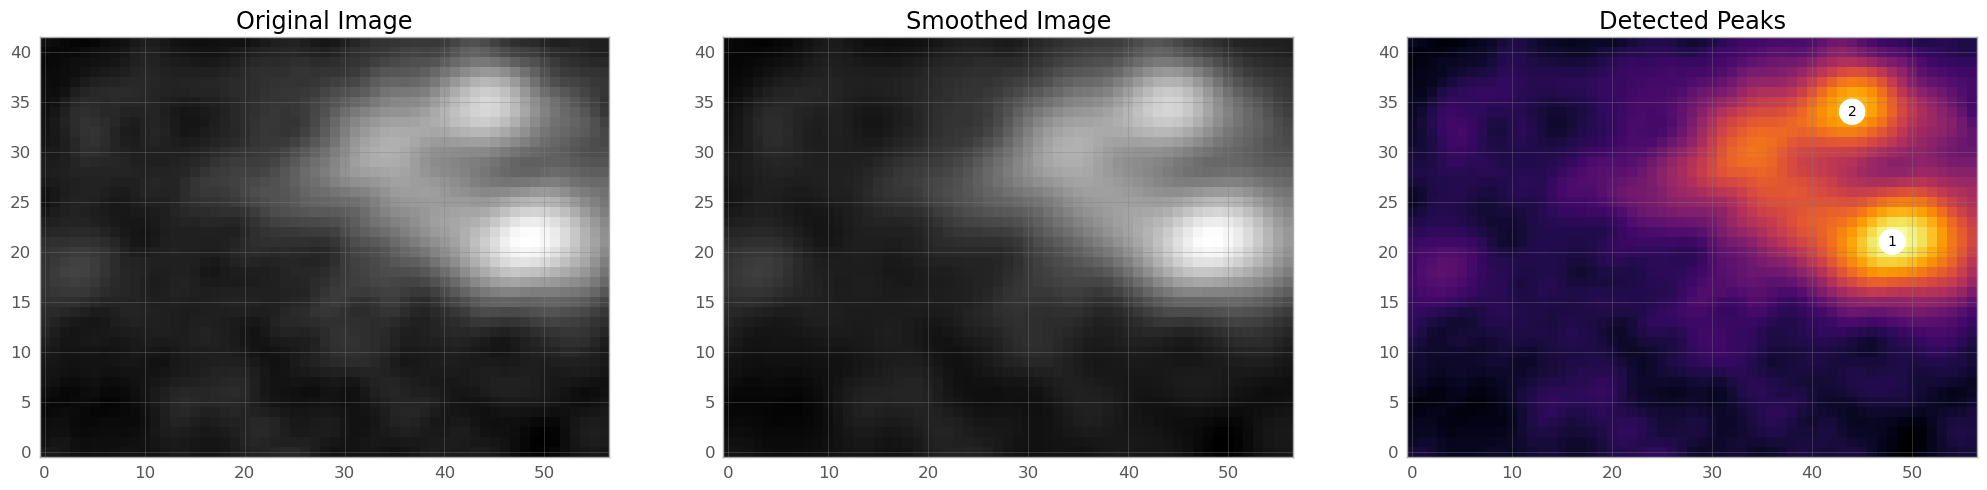

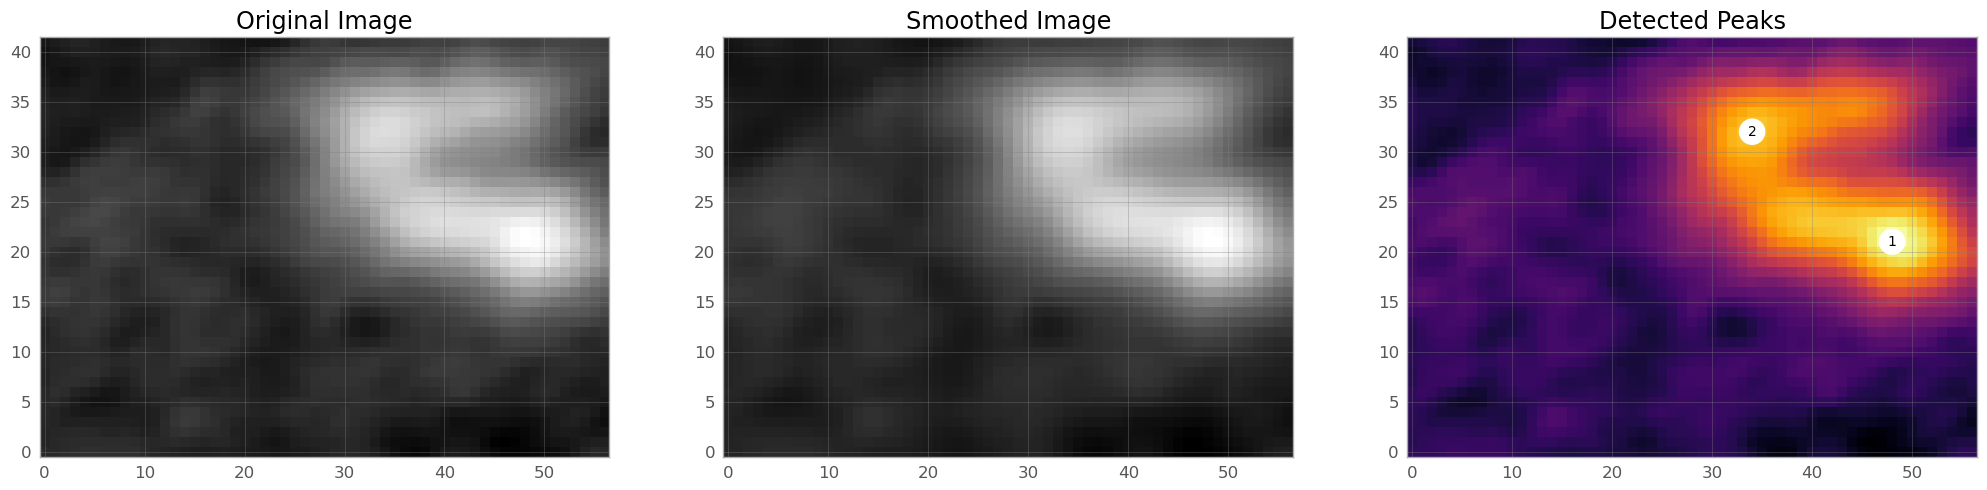

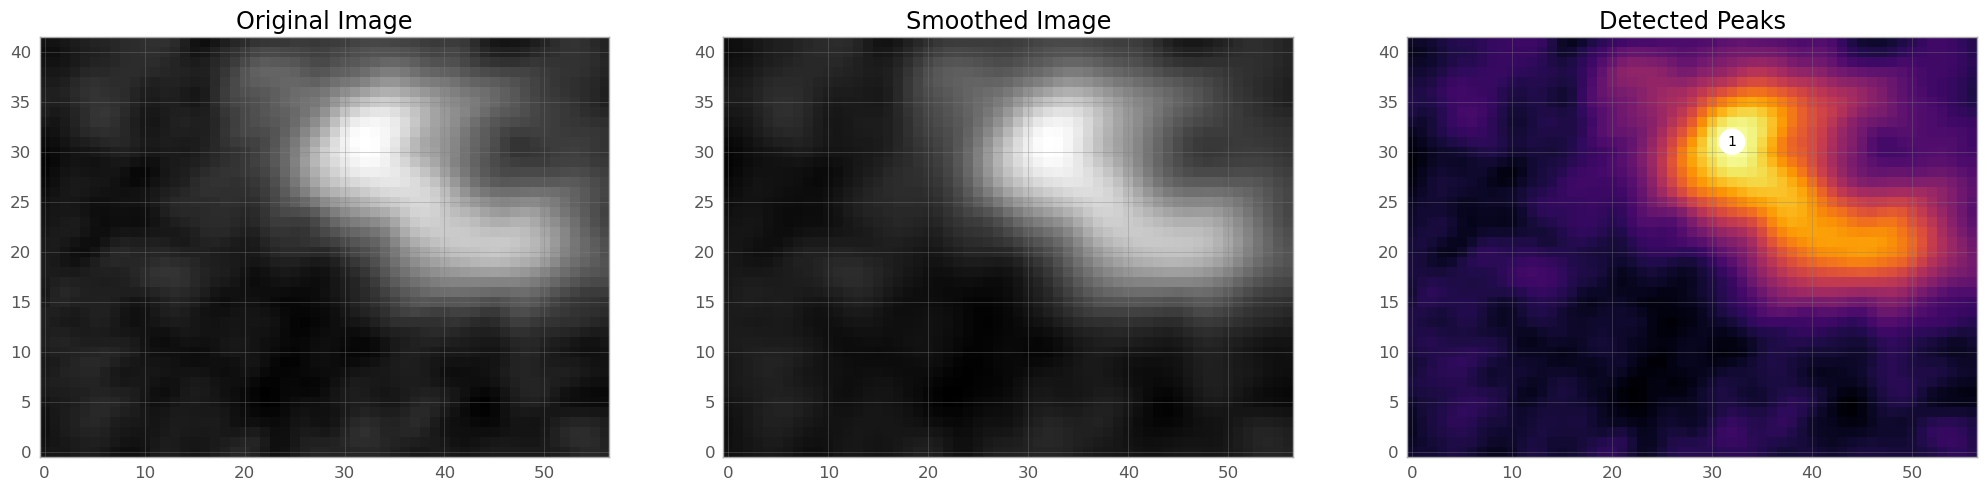

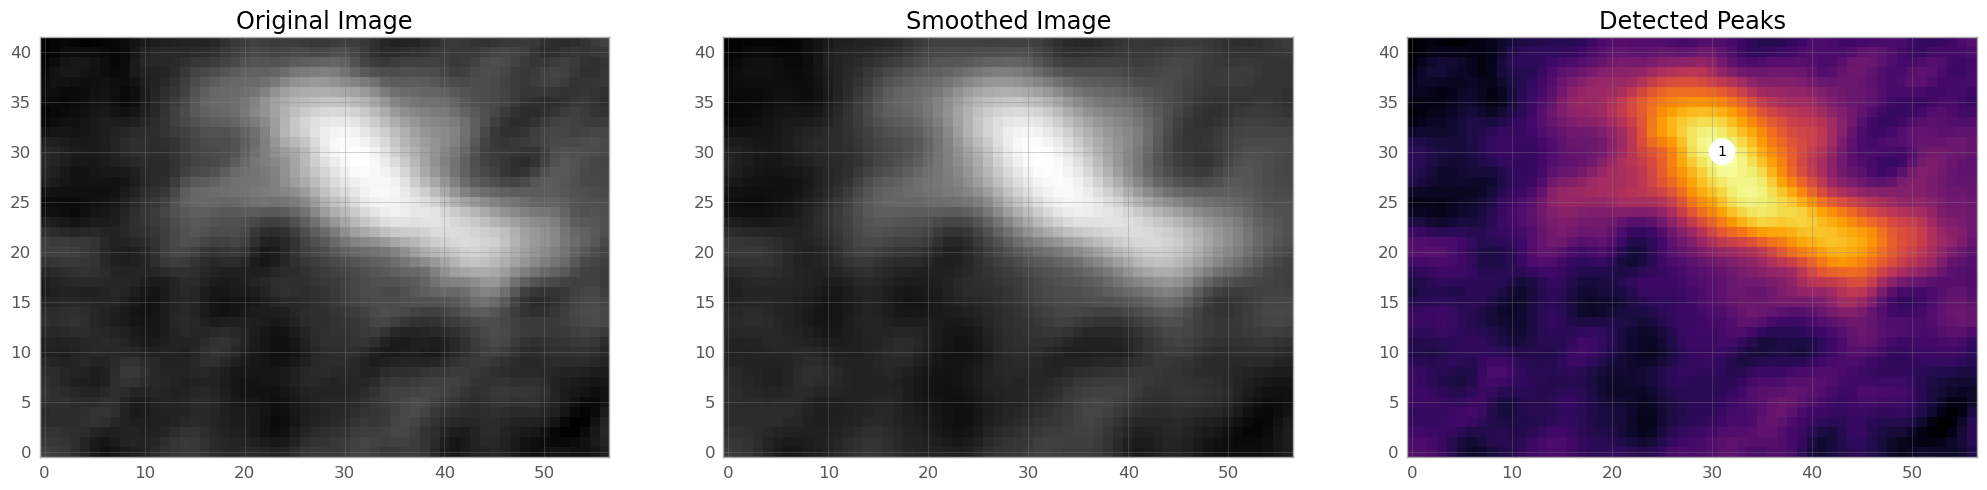

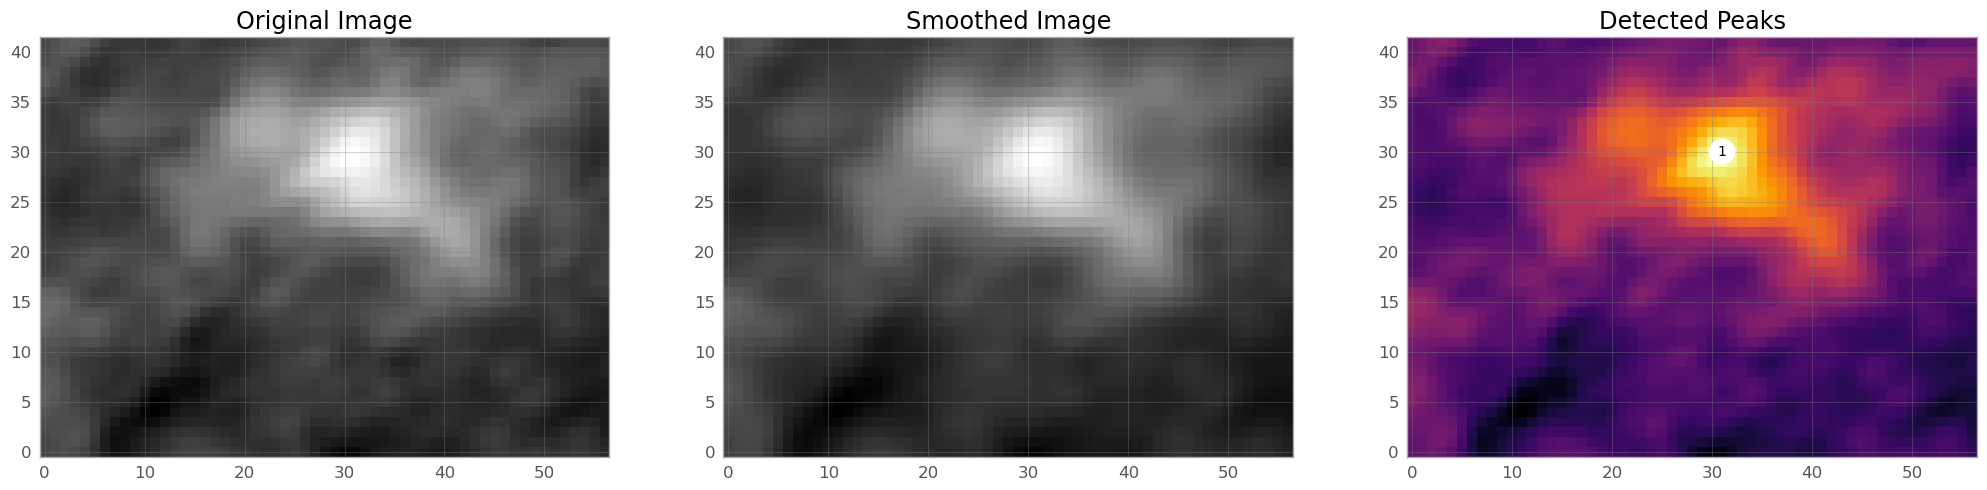

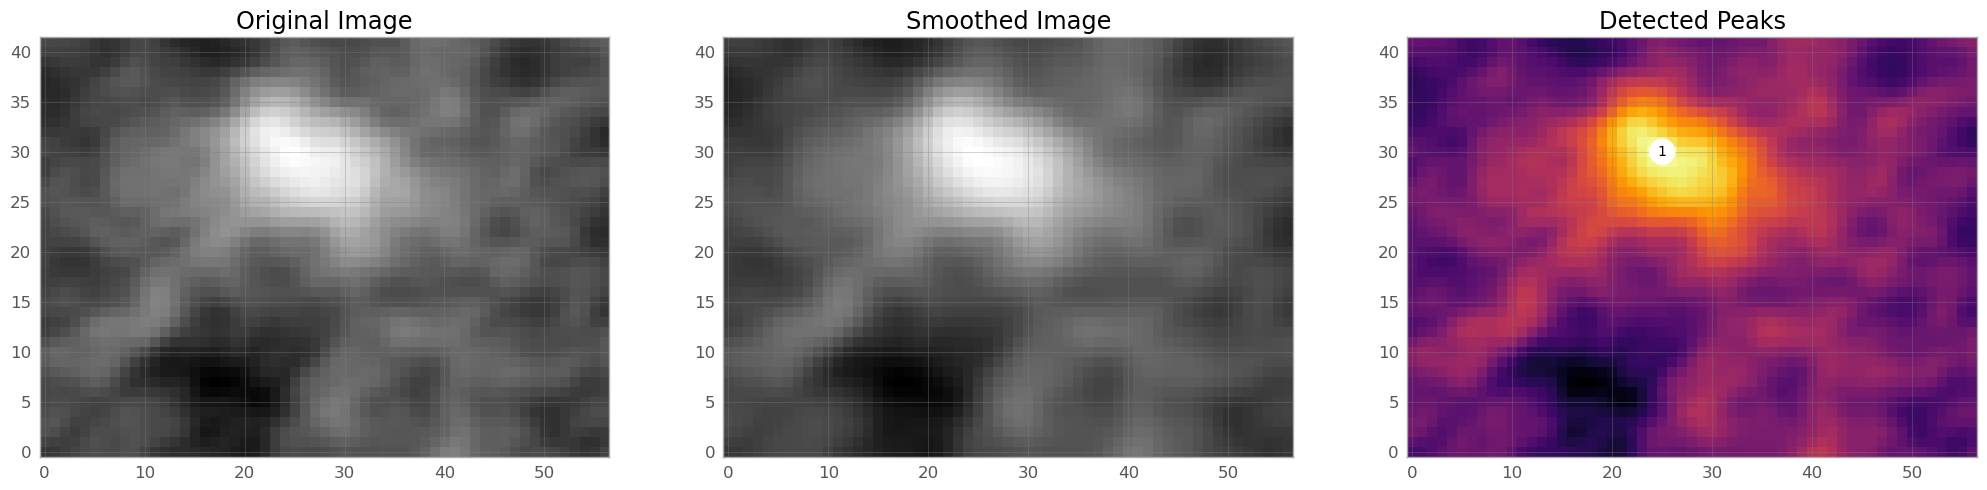

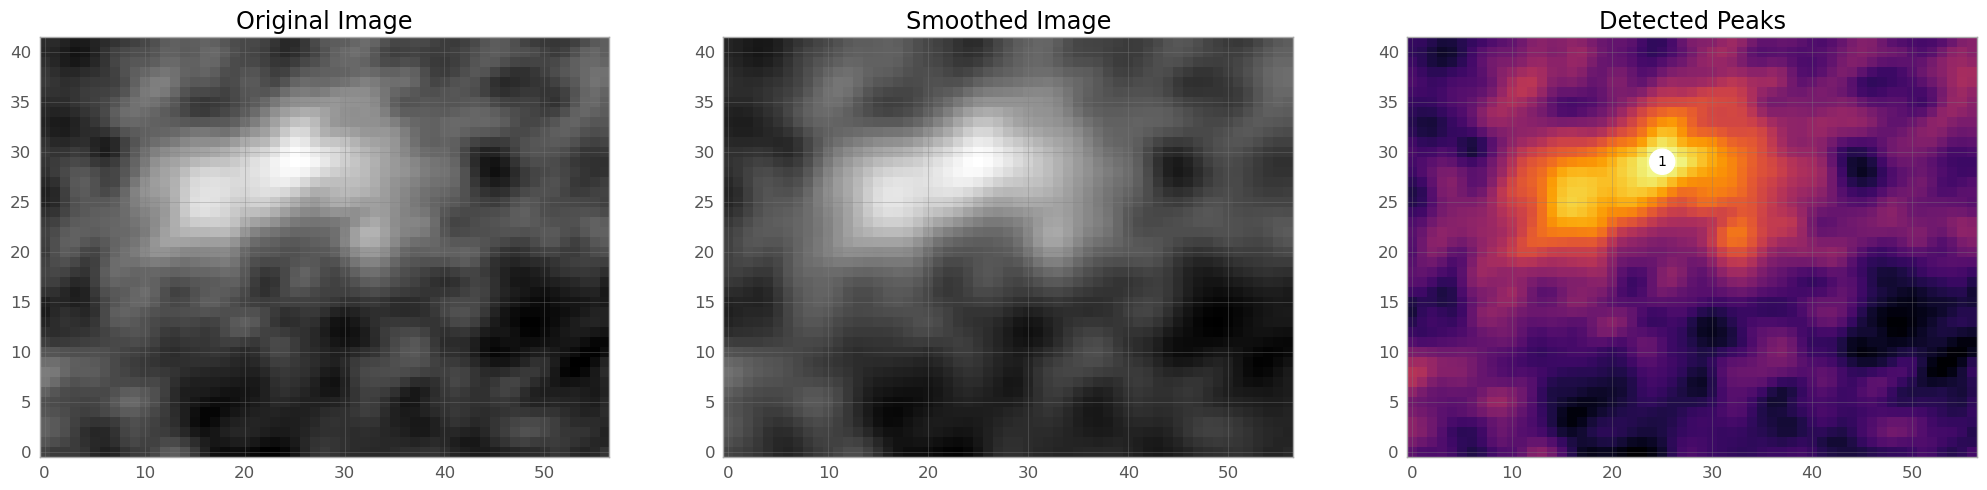

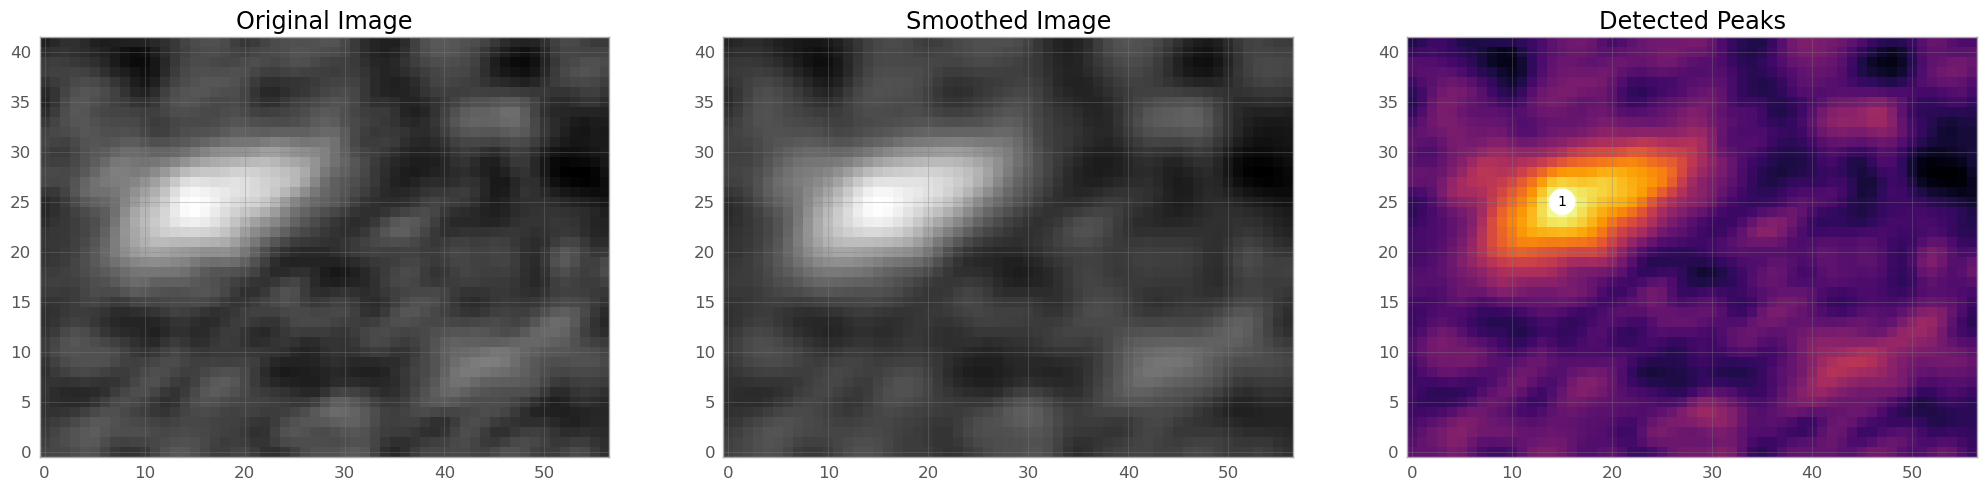

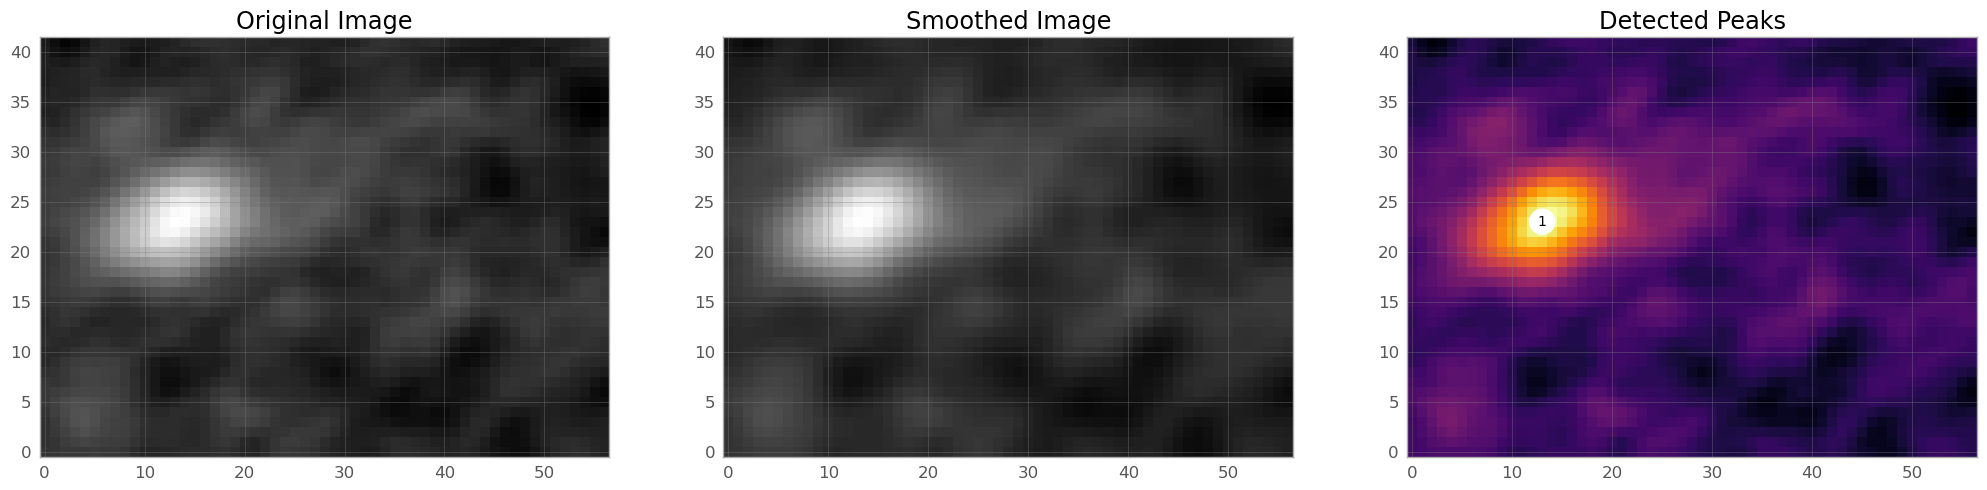

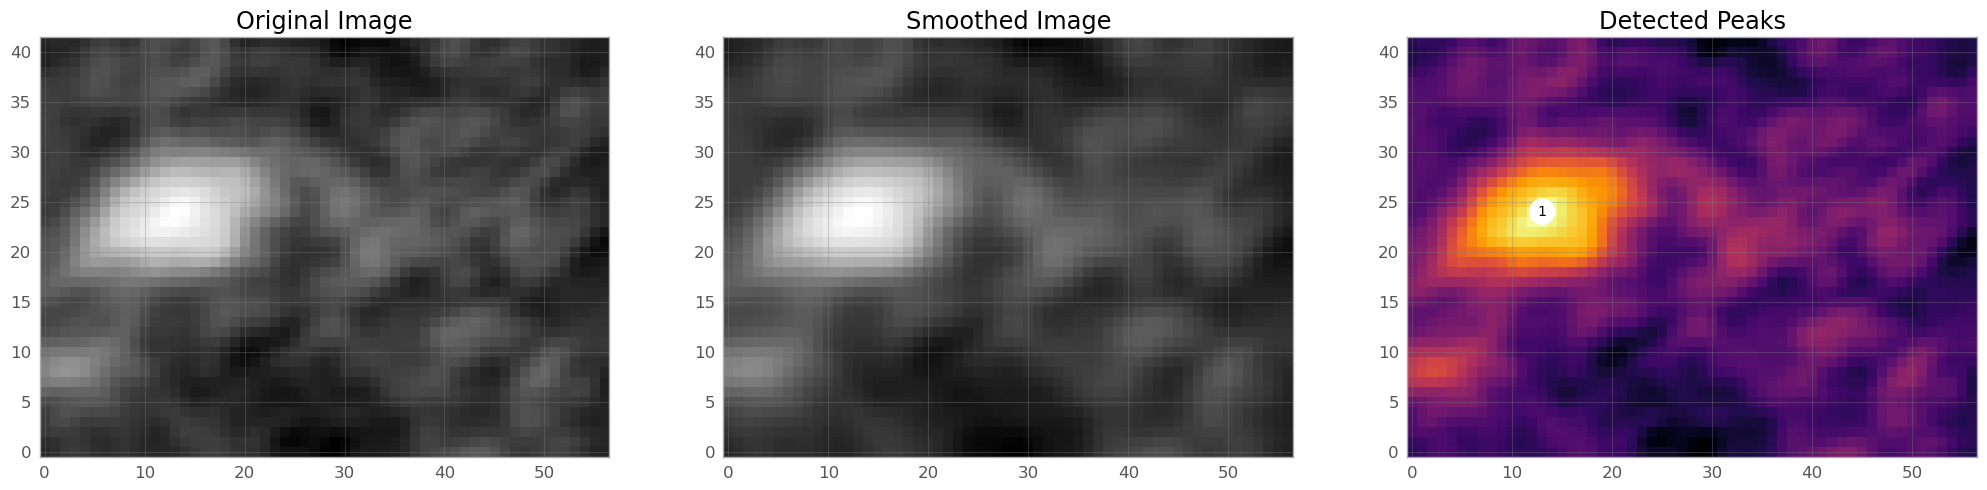

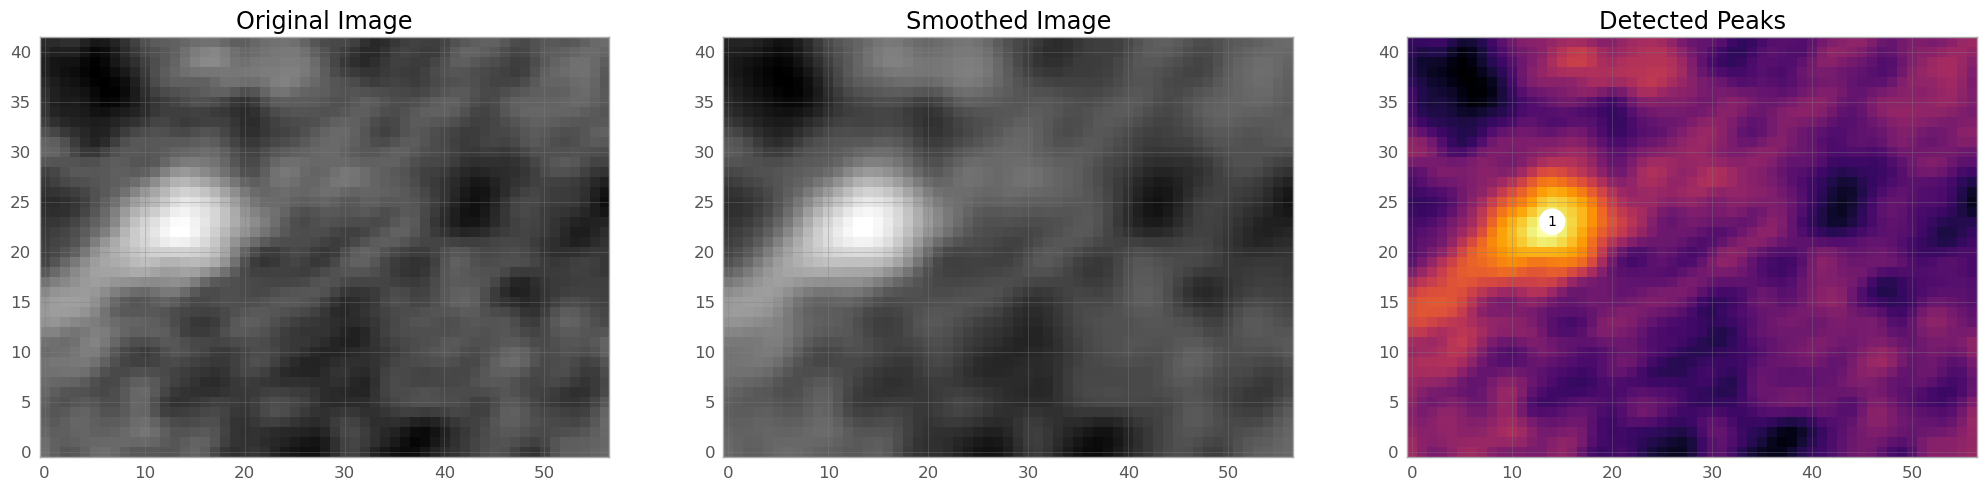

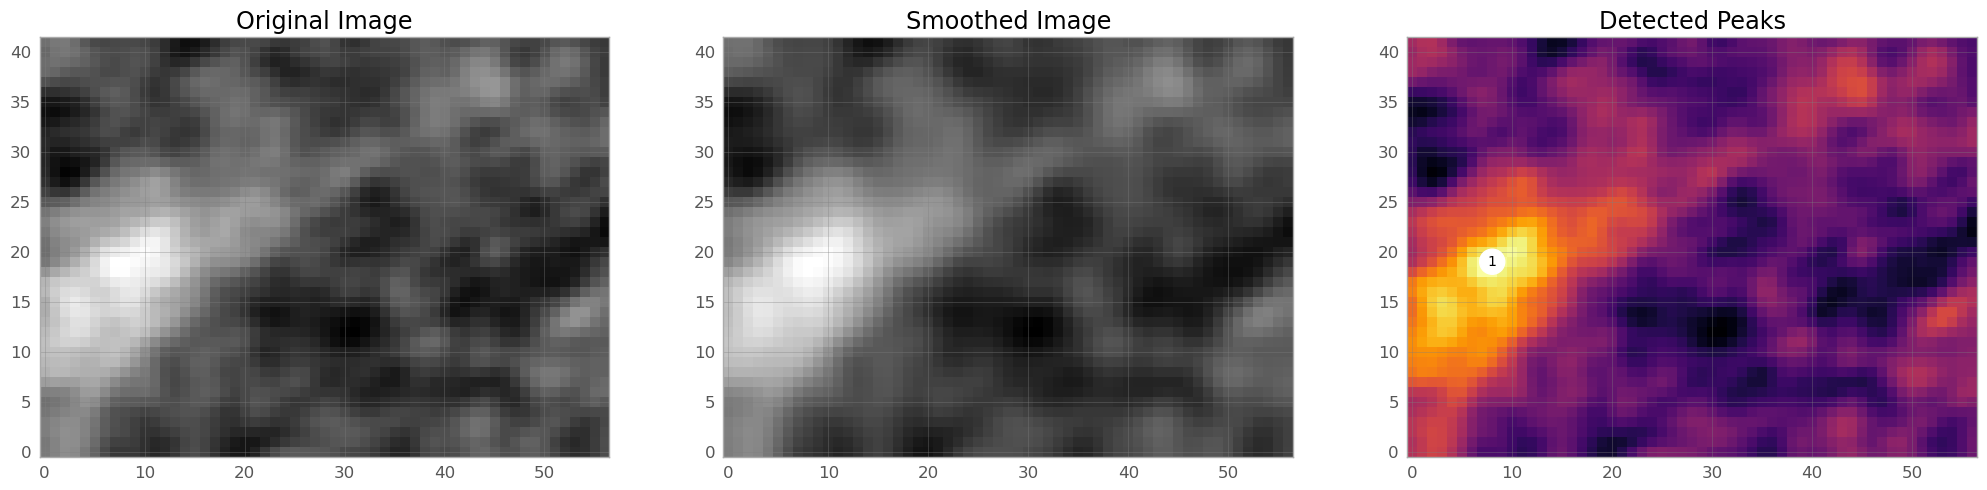

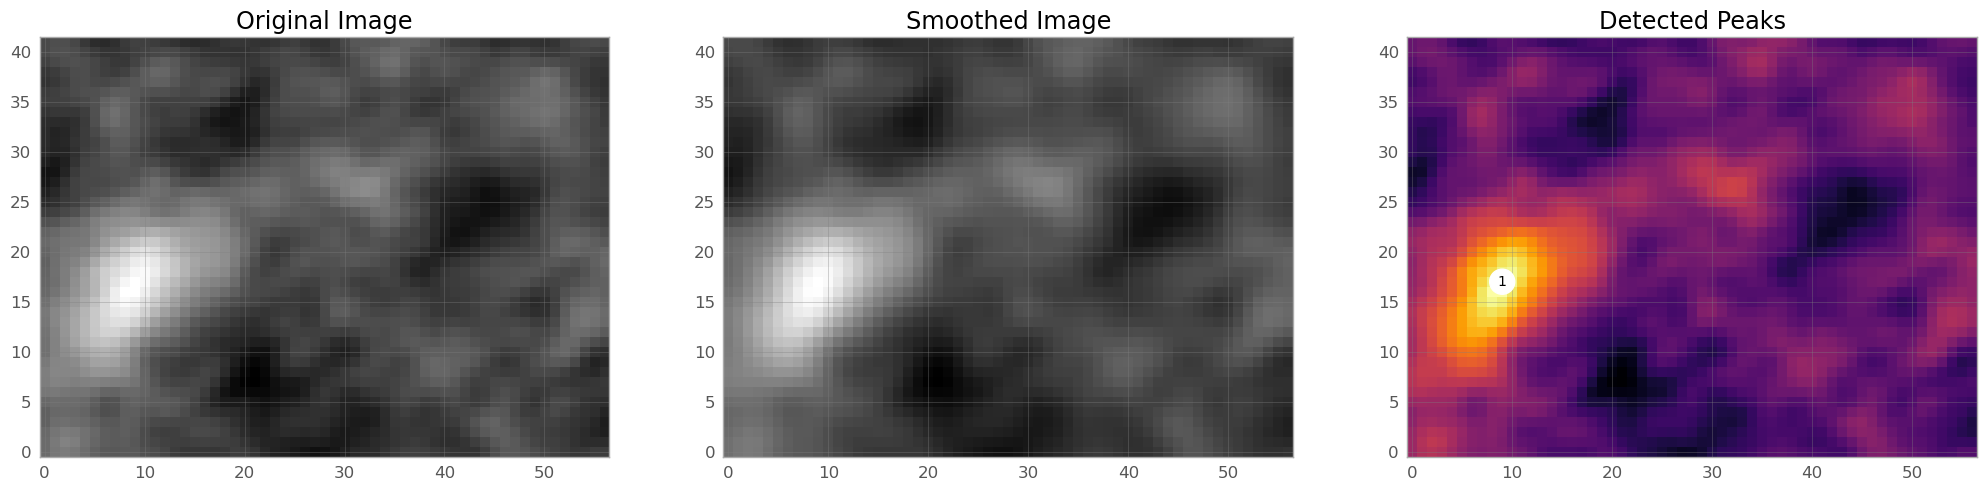

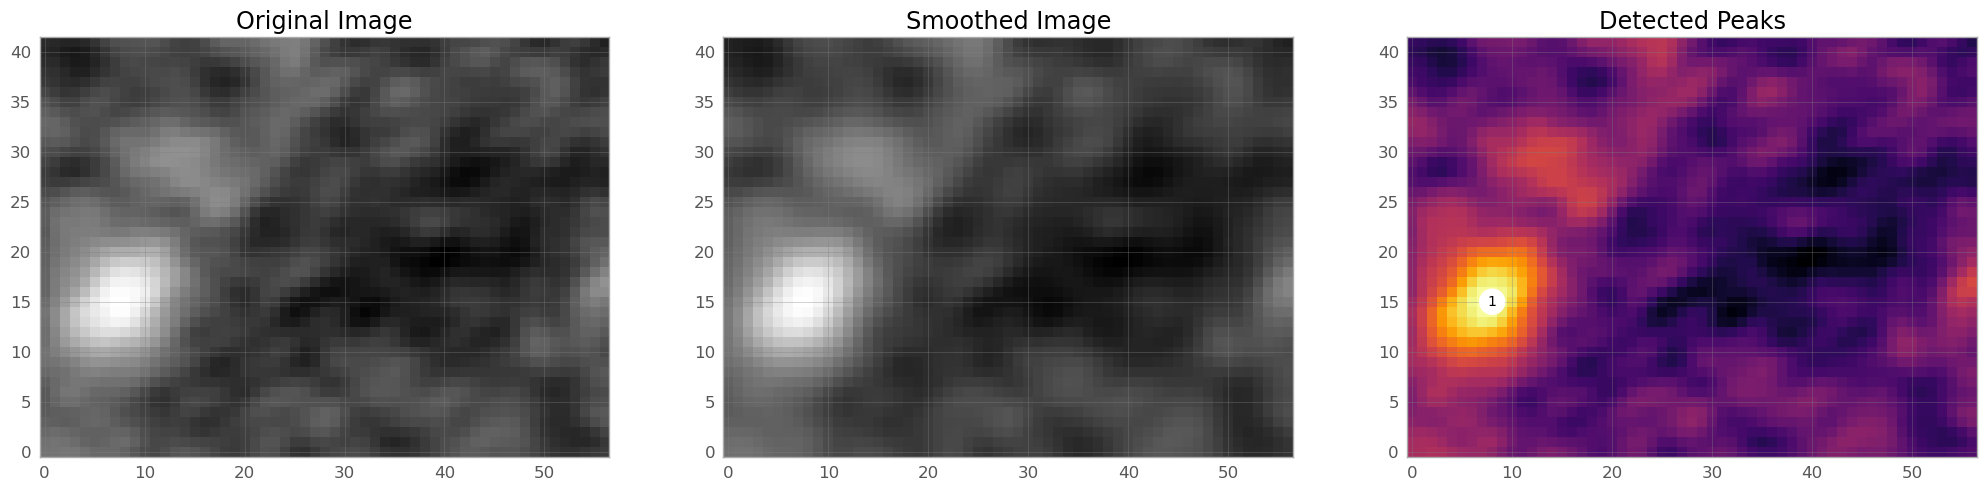

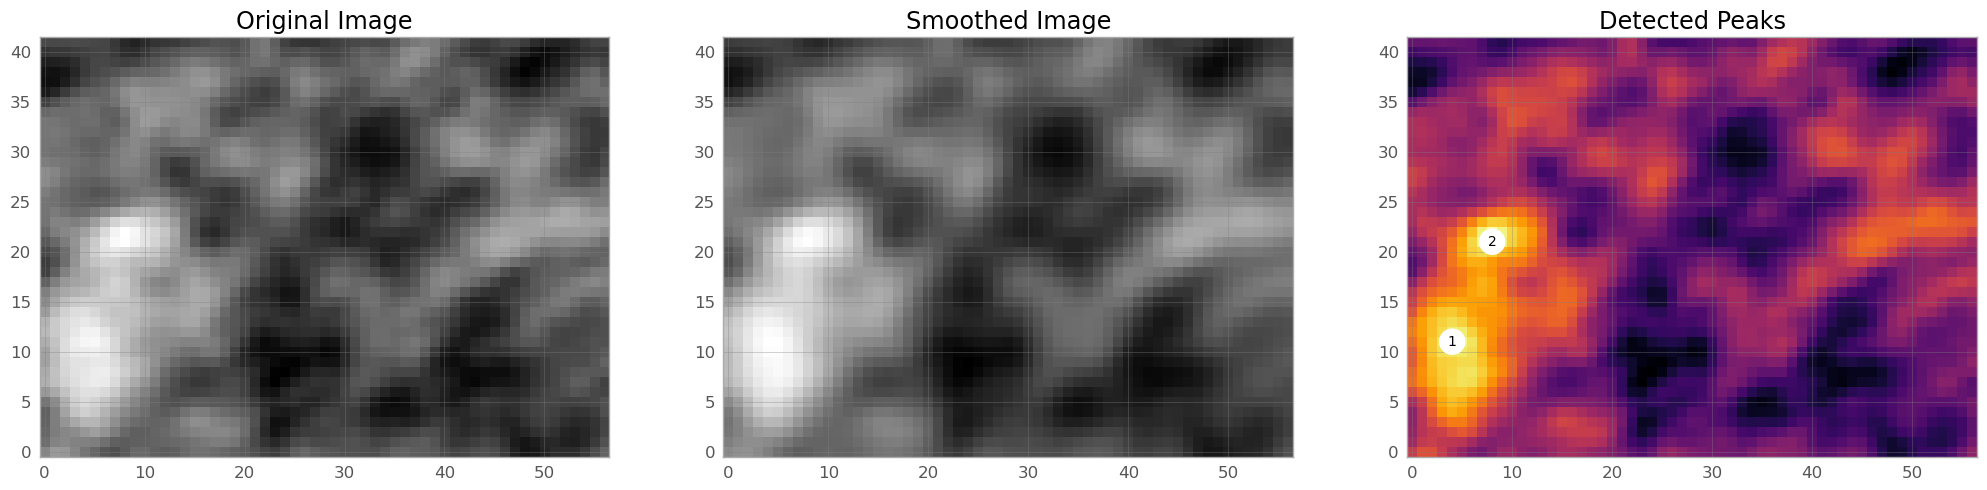

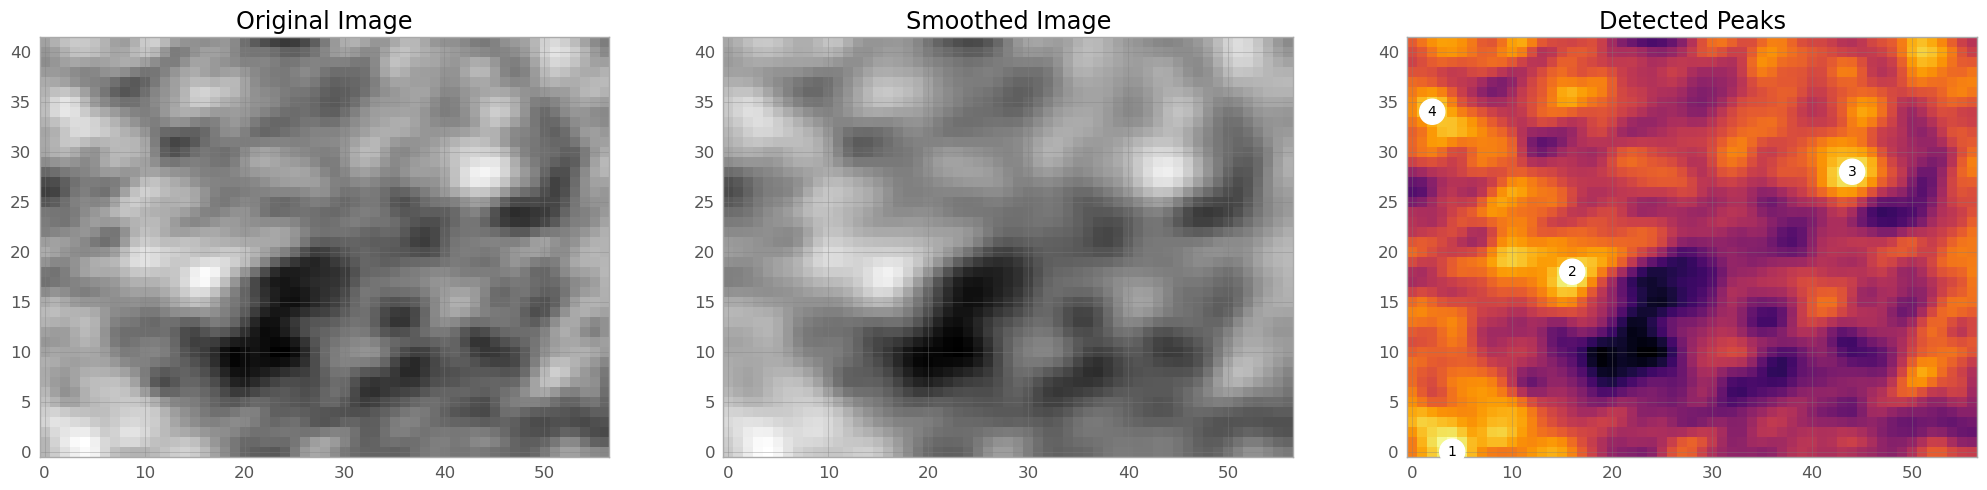

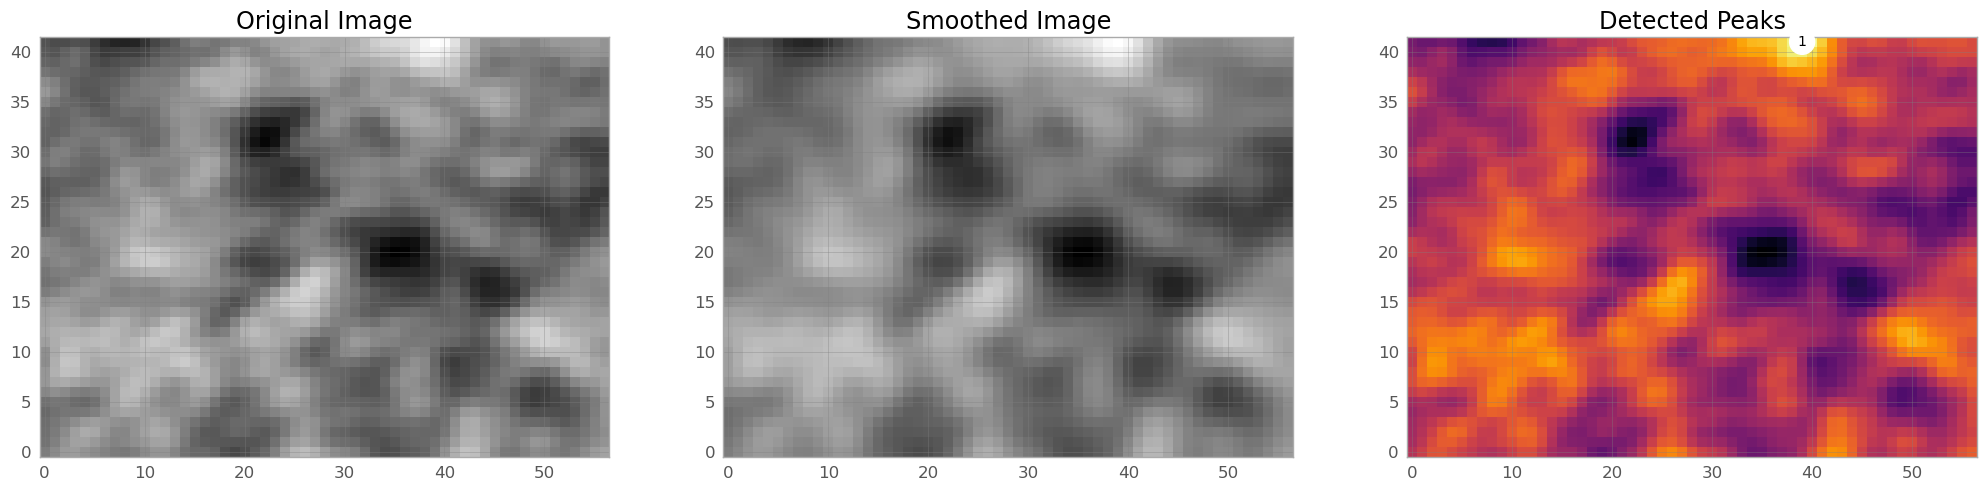

In [494]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter, gaussian_filter


def detect_peaks(image, threshold_pct, plot=False):
    # Optionally smooth the image with a Gaussian filter to reduce noise
    smoothed_image = gaussian_filter(image, sigma=1)

    # Apply a maximum filter to the smoothed image
    neighborhood_size = 10  # Define the size of the neighborhood
    local_max = maximum_filter(smoothed_image, size=neighborhood_size) == smoothed_image

    # Create a mask that identifies the peaks
    detected_peaks = smoothed_image * local_max

    coordinates = np.where(detected_peaks > 0)
    coordinates_list = list(zip(coordinates[0], coordinates[1]))
    chosen_coords = []

    for coords in coordinates_list:
        if image[coords]>np.max(image) * threshold_pct:
            chosen_coords.append(coords)

    if plot:
        plt.figure(figsize = (25,10))
        # Plot the original image, the smoothed image, and the detected peaks
        plt.subplot(1, 3, 1)
        plt.title('Original Image')
        plt.imshow(image, cmap='gray')

        plt.subplot(1, 3, 2)
        plt.title('Smoothed Image')
        plt.imshow(smoothed_image, cmap='gray')

        bbox_props = dict(boxstyle="circle,pad=0.4", fc="white", ec="white", lw=1)
        plt.subplot(1, 3, 3)
        plt.title('Detected Peaks')
        im = plt.imshow(image, cmap='inferno', origin='lower')
        for i in range(len(chosen_coords)):
            plt.text(chosen_coords[i][1], chosen_coords[i][0], str(i+1), color="k", ha='center', va='center', size=10, bbox = bbox_props)
        plt.show()

    return chosen_coords

all_peaks = []
slices = []

for slice in range(masked_boxed_cube.shape[0]):
    image = boxed_cube[slice].value
    threshold_pct = 0.8
    peaks = detect_peaks(image, threshold_pct, plot=False)
    all_peaks.append(peaks)
    slices.append(slice)



{0: [(35, 31)], 1: [(35, 30)], 2: [(34, 30)], 3: [(35, 30)], 4: [(34, 29)], 5: [(34, 30)], 6: [(33, 30)], 7: [(32, 30)], 8: [(20, 53), (31, 31)], 9: [(20, 50), (34, 43)], 10: [(21, 50), (34, 44)], 11: [(21, 48), (34, 44)], 12: [(21, 48), (32, 34)], 13: [(31, 32)], 14: [(30, 31)], 15: [(30, 31)], 16: [(30, 25)], 17: [(29, 25)], 18: [(25, 15)], 19: [(23, 13)], 20: [(24, 13)], 21: [(23, 14)], 22: [(19, 8)], 23: [(17, 9)], 24: [(15, 8)], 25: [(11, 4), (21, 8)]}


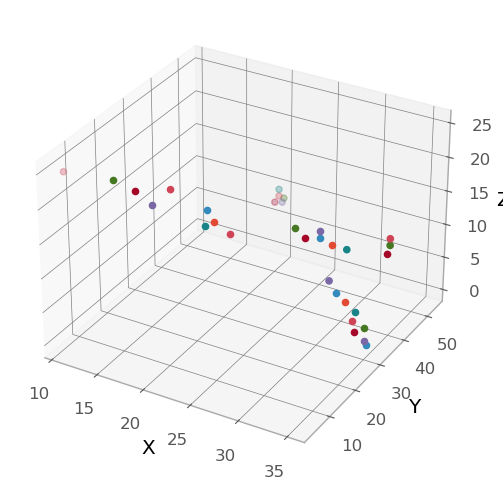

In [500]:
# Initialize an empty dictionary
slices_dict = {}

# Populate the dictionary using a for loop
for i, slice_index in enumerate(slices[:-2]):
    slices_dict[slice_index] = all_peaks[i]

# Print the resulting dictionary
print(slices_dict)

# Create a new figure
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot each slice
for z, points in slices_dict.items():
    x, y = zip(*points)
    ax.scatter(x, y, zs=z, label=f'z={z}')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

#ax.legend()
plt.show()


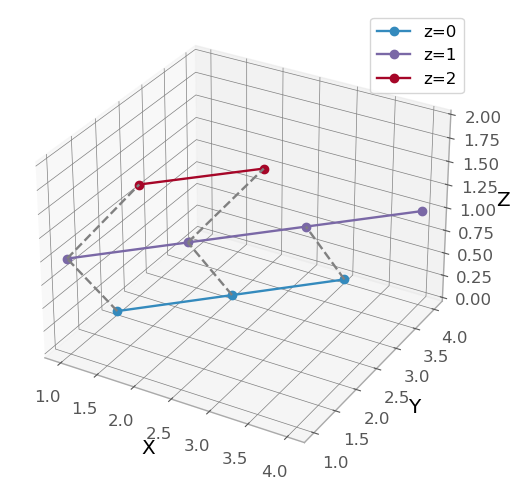

In [476]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


# Example data with different number of connections
slices = {
    0: [(1, 2), (2, 3), (3, 4)],
    1: [(1, 1), (2, 2), (3, 3), (4, 4)],
    2: [(2, 1), (3, 2)]
}

# Create a new figure
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot each slice
for z, points in slices.items():
    x, y = zip(*points)
    ax.plot(x, y, zs=z, marker='o', label=f'z={z}')

# Connect points across slices
z_values = sorted(slices.keys())
for i in range(len(z_values) - 1):  # Exclude the last slice
    z = z_values[i]
    next_z = z_values[i + 1]
    points = slices[z]
    next_points = slices[next_z]
    
    min_len = min(len(points), len(next_points))
    for j in range(min_len):
        (x1, y1) = points[j]
        (x2, y2) = next_points[j]
        ax.plot([x1, x2], [y1, y2], [z, next_z], color='gray', linestyle='--')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.legend()
plt.show()



In [ ]:
import numpy as np
from scipy.ndimage.filters import maximum_filter
from scipy.ndimage.morphology import generate_binary_structure, binary_erosion
import matplotlib.pyplot as plt

"""
Takes an image and detect the peaks usingthe local maximum filter.
Returns a boolean mask of the peaks (i.e. 1 when
the pixel's value is the neighborhood maximum, 0 otherwise)
"""

# define an 8-connected neighborhood
neighborhood = generate_binary_structure(2,2)

#apply the local maximum filter; all pixel of maximal value 
#in their neighborhood are set to 1
local_max = maximum_filter(image, footprint=neighborhood)==image
#local_max is a mask that contains the peaks we are 
#looking for, but also the background.
#In order to isolate the peaks we must remove the background from the mask.

#we create the mask of the background
background = (image==0)

#a little technicality: we must erode the background in order to 
#successfully subtract it form local_max, otherwise a line will 
#appear along the background border (artifact of the local maximum filter)
eroded_background = binary_erosion(background, structure=neighborhood, border_value=1)

#we obtain the final mask, containing only peaks, 
#by removing the background from the local_max mask (xor operation)
detected_peaks = local_max ^ eroded_background


slice = 10

detected_peaks = detect_peaks(boxed_cube[slice].value)
plt.imshow(boxed_cube[slice].value)
plt.show()
plt.imshow(detected_peaks)
plt.show()

/var/folders/bp/qbk6vrmx3vz8pnjkwdvk9_b40000gn/T/ipykernel_3302/2546654740.py:2: DeprecationWarning: Please import `maximum_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import maximum_filter
/var/folders/bp/qbk6vrmx3vz8pnjkwdvk9_b40000gn/T/ipykernel_3302/2546654740.py:3: DeprecationWarning: Please import `generate_binary_structure` from the `scipy.ndimage` namespace; the `scipy.ndimage.morphology` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.morphology import generate_binary_structure, binary_erosion
/var/folders/bp/qbk6vrmx3vz8pnjkwdvk9_b40000gn/T/ipykernel_3302/2546654740.py:3: DeprecationWarning: Please import `binary_erosion` from the `scipy.ndimage` namespace; the `scipy.ndimage.morphology` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.morphology import generate_binary_structure, binary_erosion


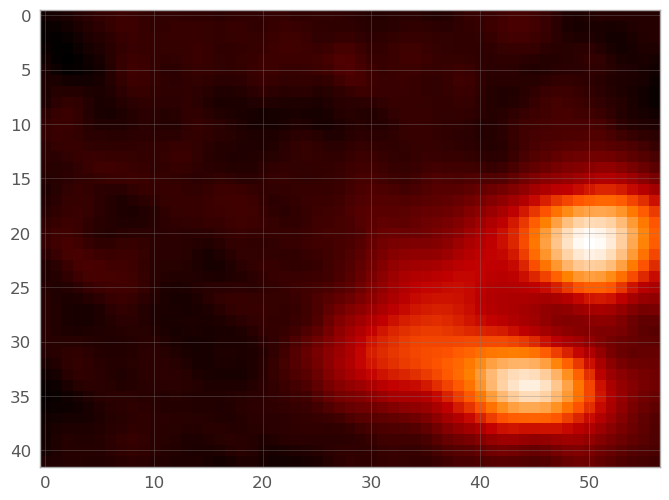

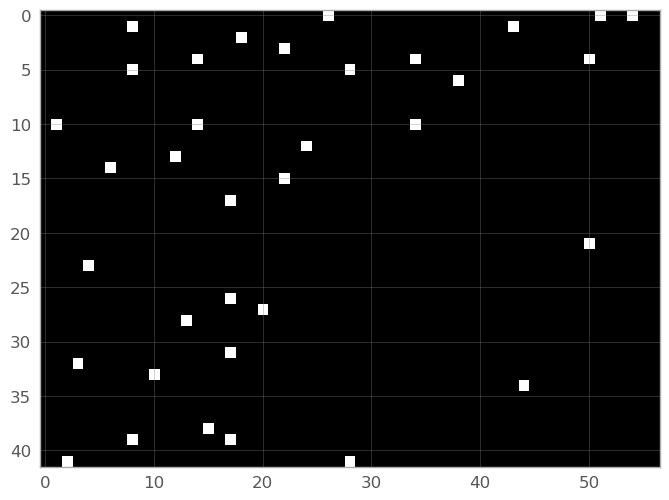

In [40]:
import numpy as np
from scipy.ndimage.filters import maximum_filter
from scipy.ndimage.morphology import generate_binary_structure, binary_erosion
import matplotlib.pyplot as plt

def detect_peaks(image):
    """
    Takes an image and detect the peaks usingthe local maximum filter.
    Returns a boolean mask of the peaks (i.e. 1 when
    the pixel's value is the neighborhood maximum, 0 otherwise)
    """

    # define an 8-connected neighborhood
    neighborhood = generate_binary_structure(2,2)

    #apply the local maximum filter; all pixel of maximal value 
    #in their neighborhood are set to 1
    local_max = maximum_filter(image, footprint=neighborhood)==image
    #local_max is a mask that contains the peaks we are 
    #looking for, but also the background.
    #In order to isolate the peaks we must remove the background from the mask.

    #we create the mask of the background
    background = (image==0)

    #a little technicality: we must erode the background in order to 
    #successfully subtract it form local_max, otherwise a line will 
    #appear along the background border (artifact of the local maximum filter)
    eroded_background = binary_erosion(background, structure=neighborhood, border_value=1)

    #we obtain the final mask, containing only peaks, 
    #by removing the background from the local_max mask (xor operation)
    detected_peaks = local_max ^ eroded_background

    return detected_peaks

slice = 10

detected_peaks = detect_peaks(boxed_cube[slice].value)
plt.imshow(boxed_cube[slice].value)
plt.show()
plt.imshow(detected_peaks)
plt.show()

[]


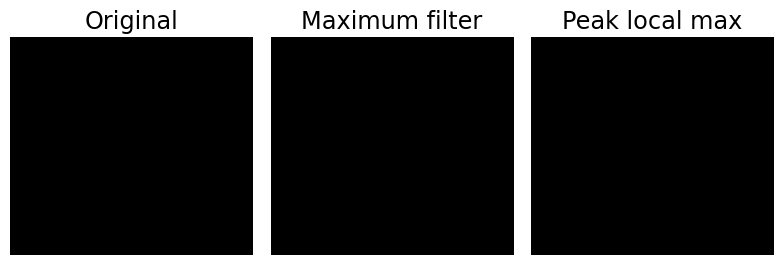

In [15]:
from scipy import ndimage as ndi
import matplotlib.pyplot as plt
from skimage.feature import peak_local_max
from skimage import data, img_as_float

#im = img_as_float(data.coins())

im = masked_boxed_cube[10].value

# image_max is the dilation of im with a 20*20 structuring element
# It is used within peak_local_max function
image_max = ndi.maximum_filter(im, size=20, mode='constant')

# Comparison between image_max and im to find the coordinates of local maxima
coordinates = peak_local_max(im, min_distance=50)
print(coordinates)
# display results
fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharex=True, sharey=True)
ax = axes.ravel()
ax[0].imshow(im, cmap=plt.cm.gray)
ax[0].axis('off')
ax[0].set_title('Original')

ax[1].imshow(image_max, cmap=plt.cm.gray)
ax[1].axis('off')
ax[1].set_title('Maximum filter')

ax[2].imshow(im, cmap=plt.cm.gray)
ax[2].autoscale(False)
ax[2].plot(coordinates[:, 1], coordinates[:, 0], 'r.')
ax[2].axis('off')
ax[2].set_title('Peak local max')

fig.tight_layout()

plt.show()